# 05 - Author Analysis

## Objective
- Calculate author influence metrics (Gini, NAHHI, Top 30%)
- Identify Highly IGO-Cited Scientists (HIC-Sci)
- Analyze author coverage of IGO-cited papers (cumulative curves)
- Calculate Rich-Club coefficient
- Analyze international co-authorship rates
- LCC analysis of author co-authorship networks

## Inputs
- `tmp/policy_cited_paper.pickle`: IGO-cited paper data
- `tmp/partition_info.pickle`: Cluster information
- Scopus: author_name, af_country, af_name

## Outputs
- `tmp/hic_sci_list.pickle`: Highly IGO-Cited Scientists list
- `tmp/author_metrics.pickle`: Author metrics (gini, nahhi, top30)
- `output/fig2_b_ccdf.eps`: Paper coverage CCDF
- `output/fig2_c_top30_comparison.eps`: Top 30% comparison
- `output/fig2_e_lcc_vs_top30.eps`: LCC size vs Top 30%
- `output/fig4_intl_coauthor.eps`: International co-authorship rate
- `output/figS_power.eps`: Author distribution power law

In [ ]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import collections
import itertools
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import igraph as ig
import warnings
import scienceplots
import glob
import os
from adjustText import adjust_text
from collections import defaultdict

from config.settings import TmpPaths, OutputPaths, SCOPUS_BASE, POLICY_CITE_BASE, PARTITION_COLORS, PARTITION_NAMES
from src.utils import flatten2, gini

%matplotlib inline
%config InlineBackend.figure_format='retina'
plt.style.use(['science', 'no-latex'])
warnings.filterwarnings('ignore')

partition_abbr = {
    "Economy and Finance": "Econ & Finance",
    "Environmental Conservation": "Env. Conserv.",
    "Healthcare": "Healthcare",
    "Energy Policy": "Energy",
    "Education System": "Education",
    "Marine Conservation": "Marine Conserv.",
    "Climate Modeling": "Climate Modeling",
    "Social Welfare": "Social Welfare",
    "Covid19 Pandemic": "COVID-19",
    "Urban Planning": "Urban Plan.",
    "Infectious Diseases": "Infect. Dis.",
    "Antibiotic Resistance": "Antibtic. Resist.",
    "Public Health": "Public Health",
    "Urban Mobility": "Urban Mobility",
    "Plastic Pollution": "Plastic Pollut.",
    "Drug Forensics": "Drug Forensics",
    "Data Science & AI": "Data Sci. & AI",
    "Data Science and AI": "Data Sci. & AI",    
    "Vector-Borne Diseases": "Vector-Borne Dis.",
    "Vaccination": "Vaccination",
    "Circular Economy": "Circular Econ.",
    "Animal Diseases": "Animal Dis.",
    "Environmental Toxicology": "Env. Toxicol.",
    "Tobacco Control": "Tobacco Ctrl."
}

In [ ]:

def nahhi_from_counts(counts):
    counts = pd.Series(counts).astype(float)
    if counts.empty or counts.sum() == 0: return np.nan
    shares = counts / counts.sum()
    N = shares.shape[0]
    if N <= 1: return 1.0
    hhi = float((shares**2).sum())
    return (hhi - 1.0/N) / (1.0 - 1.0/N)

def kamada(G):
    g = ig.Graph.TupleList(pd.DataFrame(G.edges()).itertuples(index=False), directed=False)
    return {v['name']: p for v, p in zip(g.vs(), g.layout_kamada_kawai())}

In [3]:

policy_cited_scopus = pd.read_pickle(TmpPaths.POLICY_CITED_PAPER)
partition_info = pd.read_pickle(TmpPaths.PARTITION_INFO)

author_name = pd.read_pickle(f'{SCOPUS_BASE}/author/author_name.pickle')
af_country = pd.read_pickle(f'{SCOPUS_BASE}/affiliation/af_country.pickle')
af_name = pd.read_pickle(f'{SCOPUS_BASE}/affiliation/af_name2.pickle')

color_list = PARTITION_COLORS

print(f"Policy cited papers: {len(policy_cited_scopus):,}")
print(f"Partitions: {partition_info.index.tolist()}")

Policy cited papers: 230,737
Partitions: [-1.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0]


In [4]:

print("Loading detailed citation data for time-series analysis...")
df_all = pd.concat([
    pd.read_csv(f, on_bad_lines='skip', encoding='latin-1') 
    for f in glob.glob(str(POLICY_CITE_BASE / 'detaild_data' / 'articles-202*.csv'))
])
df_all.index = range(len(df_all))


if 'eid' not in policy_cited_scopus.columns:
    policy_cited_scopus['eid'] = policy_cited_scopus.index

df_all['eid'] = df_all.DOI.map(policy_cited_scopus.set_index('doi').eid)
df_all['cyear'] = df_all['Cited by date'].apply(lambda x: int(x.split("-")[0]) if isinstance(x, str) and x.startswith('2') else None)
df_all['year'] = df_all['Published on'].apply(lambda x: int(x[:4]) if isinstance(x, str) else None)

df_all['ym'] = df_all['Published on'].apply(lambda x: int(x[:4])*100 + int(x[5:7]) if isinstance(x, str) and len(x)>=7 else 0)
df_all['cym'] = df_all['cyear'].fillna(0) * 100 + df_all['Cited by date'].apply(lambda x: int(x.split("-")[1]) if isinstance(x, str) and x.startswith('2') else 0)


df_all_ = df_all.query('cym - ym <= 30000 and cym >= 201800').copy()

df_all_['range'] = df_all_['Cited by date'].rank(pct=True)
df_all_['range'] = df_all_['range'].apply(lambda x: int(x * 3))
df_all_['range'] = df_all_['range'].apply(lambda x: 2 if x > 2 else x)

for y in [0, 1, 2]:
    eidy = set(df_all_.query('range == @y').eid)
    policy_cited_scopus[y] = policy_cited_scopus['eid'].apply(lambda x: 1 if x in eidy else 0)

print("Time periods defined:")
for i in range(3):
    min_date = df_all_.query('range == @i')['Cited by date'].min()
    max_date = df_all_.query('range == @i')['Cited by date'].max()
    count = policy_cited_scopus[i].sum()
    print(f"  Period {i}: {min_date} ~ {max_date} (Papers cited: {count})")

Loading detailed citation data for time-series analysis...
Time periods defined:
  Period 0: 2018-01-01 ~ 2020-11-23 (Papers cited: 111633)
  Period 1: 2020-11-24 ~ 2022-06-23 (Papers cited: 131134)
  Period 2: 2022-06-24 ~ 2024-11-28 (Papers cited: 131505)


In [5]:

def build_author_aggregation(df_part, impact_fractional=False):
    vv = df_part.loc[df_part['authids'].map(len) <= 30].copy()
    if vv.empty:
        return pd.DataFrame(columns=['eids', 'len', 'impact', 'cumsum_eid_len', 'i'])
    
    vv = vv.explode('authids', ignore_index=True).rename(columns={'authids': 'authid'})
    
    authid_eid = vv.groupby('authid')['eid'].agg(lambda x: list(set(x))).to_frame('eids')
    authid_eid['len'] = authid_eid['eids'].map(len)
    
    if impact_fractional:
        coauth_n = vv.groupby('eid')['authid'].transform('nunique')
        impact = (1.0 / coauth_n).groupby(vv['authid']).sum()
    else:
        impact = vv.groupby('authid')['eid'].nunique()
    authid_eid['impact'] = impact.reindex(authid_eid.index).fillna(0.0)
    
    authid_eid = authid_eid.sort_values('impact', ascending=False)
    authid_eid = authid_eid.loc[[i for i in authid_eid.index if i not in [0, 2]]]
    
    eid_cumsum = set()
    cs = {}
    for j, s in authid_eid['eids'].map(set).items():
        eid_cumsum = eid_cumsum | s
        cs[j] = len(eid_cumsum)
    authid_eid['cumsum_eid_len'] = pd.Series(cs, index=authid_eid.index)
    m = authid_eid['cumsum_eid_len'].max()
    authid_eid['cumsum_eid_len'] = (authid_eid['cumsum_eid_len'] / m) if (pd.notna(m) and m > 0) else 0.0
    
    authid_eid['i'] = range(len(authid_eid))
    return authid_eid

In [ ]:

def metrics_from_partition(df_part, thr=0.3):
    df_part = df_part[df_part['authids'].apply(len) <= 30]
    
    aa = build_author_aggregation(df_part, impact_fractional=False)
    if aa.empty:
        return np.nan, np.nan, np.nan, np.nan, 0
    
    # Gini
    g = gini(aa['len'])
    
    # Top30%
    gt = aa.loc[aa['cumsum_eid_len'] > thr, 'cumsum_eid_len']
    t_thr = gt.min() if not gt.empty else np.nan
    aa['is_hic_sci'] = (aa['cumsum_eid_len'] <= t_thr)
    top30 = aa['is_hic_sci'].mean() if pd.notna(t_thr) else 0.0
    
    # NAHHI
    denom = aa['impact'].sum()
    shares = (aa['impact'] / denom) if denom > 0 else pd.Series([], dtype=float)
    nahhi = nahhi_from_counts(aa['impact'])
    
    N = aa.shape[0]
    hhi = nahhi * (1 - 1/max(N, 1)) + (1/max(N, 1)) if pd.notna(nahhi) and N > 0 else np.nan
    
    return g, float(top30), hhi, nahhi, int(df_part.shape[0])

In [7]:

def compute_all_period_metrics(policy_cited_scopus):
    sub = policy_cited_scopus.query('partition >= 0 and partition < 23').copy()
    out = []
    for k, v in sub.groupby('partition'):
        g, top30, hhi, nahhi, n = metrics_from_partition(v)
        out.append((k, g, top30, hhi, nahhi, n))
    df = pd.DataFrame(out, columns=['partition', 'gini', 'top30', 'hhi', 'nahhi', 'n_papers']).set_index('partition')
    return df

metrics_all = compute_all_period_metrics(policy_cited_scopus)
metrics_all['partition_name'] = partition_info['partition_name_GPT4']
metrics_all['color'] = pd.Series(color_list[:23])

print(metrics_all[['partition_name', 'gini', 'top30', 'nahhi', 'n_papers']])

=== 全期間の指標 ===
                       partition_name      gini     top30     nahhi  n_papers
partition                                                                    
0.0               Economy and Finance  0.325457  0.031411  0.000030     21208
1.0        Environmental Conservation  0.341006  0.011696  0.000026     15995
2.0                        Healthcare  0.287399  0.013081  0.000021     14412
3.0                     Energy Policy  0.350983  0.016471  0.000066     13165
4.0                  Education System  0.257532  0.029682  0.000025     12629
5.0               Marine Conservation  0.399946  0.008072  0.000046     12372
6.0                  Climate Modeling  0.437961  0.008300  0.000049     12064
7.0                    Social Welfare  0.325876  0.017966  0.000045     12415
8.0                  Covid19 Pandemic  0.176235  0.024597  0.000007     11386
9.0                    Urban Planning  0.273981  0.022760  0.000035     10485
10.0              Infectious Diseases  0.319720  

In [8]:

def compute_by_period_metrics(policy_cited_scopus):
    res = {}
    for y in [0, 1, 2]:
        # その期間に引用された論文のみを対象にする
        sub = policy_cited_scopus.copy()
        sub = sub.assign(tmp=sub[y]).query('tmp == 1 and partition >= 0 and partition < 23')
        
        out = []
        for k, v in sub.groupby('partition'):
            g, top30, hhi, nahhi, n = metrics_from_partition(v)
            out.append((k, g, top30, hhi, nahhi, n))
            
        dfy = pd.DataFrame(out, columns=['partition', f'gini_{y}', f'top30_{y}', f'hhi_{y}', f'nahhi_{y}', f'n_{y}']).set_index('partition')
        res[y] = dfy
        
    df = res[0].join(res[1], how='outer').join(res[2], how='outer')
    
    # 差分計算 (Period 2 - Period 0)
    df['diff_gini_2_0'] = df['gini_2'] - df['gini_0']
    df['diff_top30_2_0'] = df['top30_2'] - df['top30_0']
    df['diff_nahhi_2_0'] = df['nahhi_2'] - df['nahhi_0']
    
    return df

metrics_by_period = compute_by_period_metrics(policy_cited_scopus)
metrics_by_period['partition_name'] = partition_info['partition_name_GPT4']

print(metrics_by_period[['partition_name', 'gini_0', 'gini_1', 'gini_2', 'diff_gini_2_0']])

# 保存
# metrics_by_period.to_pickle(f'{TmpPaths.BASE}/metrics_by_period.pickle')
# print(f"Saved metrics by period to {TmpPaths.BASE}/metrics_by_period.pickle")

=== 期間別の指標 (Gini変化など) ===
                       partition_name    gini_0    gini_1    gini_2  \
partition                                                             
0.0               Economy and Finance  0.290304  0.297023  0.304687   
1.0        Environmental Conservation  0.312217  0.313486  0.303368   
2.0                        Healthcare  0.252693  0.248637  0.250642   
3.0                     Energy Policy  0.316736  0.343376  0.330351   
4.0                  Education System  0.225422  0.228829  0.231507   
5.0               Marine Conservation  0.351982  0.366780  0.360596   
6.0                  Climate Modeling  0.351463  0.413876  0.390175   
7.0                    Social Welfare  0.294932  0.298852  0.291872   
8.0                  Covid19 Pandemic  0.142210  0.146664  0.148658   
9.0                    Urban Planning  0.241063  0.256997  0.254946   
10.0              Infectious Diseases  0.275635  0.268350  0.254451   
11.0            Antibiotic Resistance  0.187661  0.

In [ ]:

authid_eids = {}
hic_sci_list = {}

thr = 0.3  

for k, v in policy_cited_scopus.query('partition < 23').groupby('partition'):
    v = v[v.authids.apply(len) <= 30]
    
    authid_eid = pd.DataFrame(
        [[a, eid] for authids, eid in zip(v.authids, v.eid) for a in authids]
    ).groupby(0)[1].agg(list).to_frame()
    authid_eid.columns = ['eids']
    
    authid_eid['impact'] = pd.DataFrame(
        flatten2(v.authids.apply(set).apply(lambda x: [[y, 1] for y in x]))
    ).groupby(0).sum()[1]
    authid_eid = authid_eid.sort_values('impact', ascending=False)
    authid_eid = authid_eid.loc[[x for x in authid_eid.index if x not in [0, 2]]]
    
    eid_cumsum = set()
    cumsum_list = []
    for j, v2 in authid_eid['eids'].apply(set).items():
        eid_cumsum = eid_cumsum | v2
        cumsum_list.append(len(eid_cumsum))
    
    authid_eid['cumsum_eid_count'] = cumsum_list
    authid_eid['cumsum_eid_ratio'] = authid_eid['cumsum_eid_count'] / authid_eid['cumsum_eid_count'].max()
    authid_eid['author_cumsum_ratio'] = (np.arange(len(authid_eid)) + 1) / len(authid_eid)
    
    authors_for_30 = authid_eid[authid_eid['cumsum_eid_ratio'] >= thr]
    if len(authors_for_30) > 0:
        author_count_for_30 = len(authid_eid[authid_eid['cumsum_eid_ratio'] < thr]) + 1
        authid_eid['is_hic_sci'] = [1] * author_count_for_30 + [0] * (len(authid_eid) - author_count_for_30)
        hic_sci_list[k] = list(authid_eid.iloc[:author_count_for_30].index)
    else:
        authid_eid['is_hic_sci'] = 0
        hic_sci_list[k] = []
    
    authid_eids[k] = authid_eid

pd.Series(hic_sci_list).to_pickle(TmpPaths.HIC_SCI)
print(f"HIC-Sci list saved to {TmpPaths.HIC_SCI}")

# Export Climate Modeling cluster (partition 6) for notebook 08
authid_eids[6].to_csv(TmpPaths.BASE / 'climate_modeling_authors.csv')
print(f"Saved: {TmpPaths.BASE / 'climate_modeling_authors.csv'}")

TPIS list saved to /disks/qnap4/users/t-asatani/code_final/notebooks/../tmp/top_influential_scientists.pickle


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


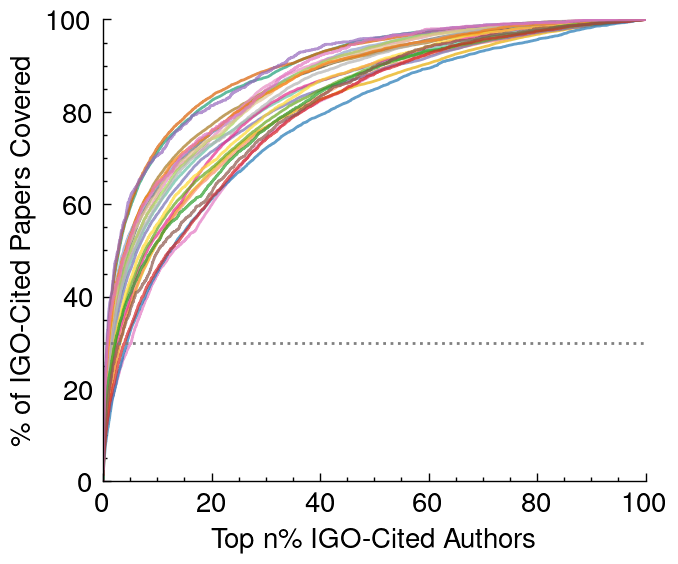

In [27]:

import matplotlib.pyplot as plt

plt.style.use(['science'])

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    # LaTeX 側でフォントを決めるため、ここで Arial は指定しない
    "axes.spines.right": False,
    "axes.spines.top": False,
})

plt.rcParams["text.latex.preamble"] = r"""
\usepackage{helvet}
\usepackage{sansmath}
\sansmath
\renewcommand{\familydefault}{\sfdefault}
"""

fig, ax = plt.subplots(figsize=(3.5, 3))

for k, v in policy_cited_scopus.query('partition < 23').groupby('partition'):
    authid_eid = authid_eids[k]
    ax.plot(authid_eid['author_cumsum_ratio'] * 100,
            authid_eid['cumsum_eid_ratio'] * 100,
            c=color_list[int(k)],
            alpha=0.7)

ax.axhline(y=30, color='gray', linestyle=':', alpha=1, label='30% coverage')

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.legend().set_visible(False)
ax.set_xlabel('Top n\% IGO-Cited Authors')
ax.set_ylabel('\% of IGO-Cited Papers Covered')

plt.savefig(f'../output/figures/fig2_b_ccdf.eps', bbox_inches='tight')
plt.savefig(f'../output/figures/fig2_b_ccdf.pdf', bbox_inches='tight')
plt.show()

In [25]:
%matplotlib inline
%config InlineBackend.figure_format='retina'
plt.style.use(['science', 'no-latex'])
warnings.filterwarnings('ignore')

plt.style.use(['science'])

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "axes.spines.right": False,
    "axes.spines.top": False,
})

plt.rcParams["text.latex.preamble"] = r"""
\usepackage{helvet}
\usepackage{sansmath}
\sansmath
\renewcommand{\familydefault}{\sfdefault}
"""



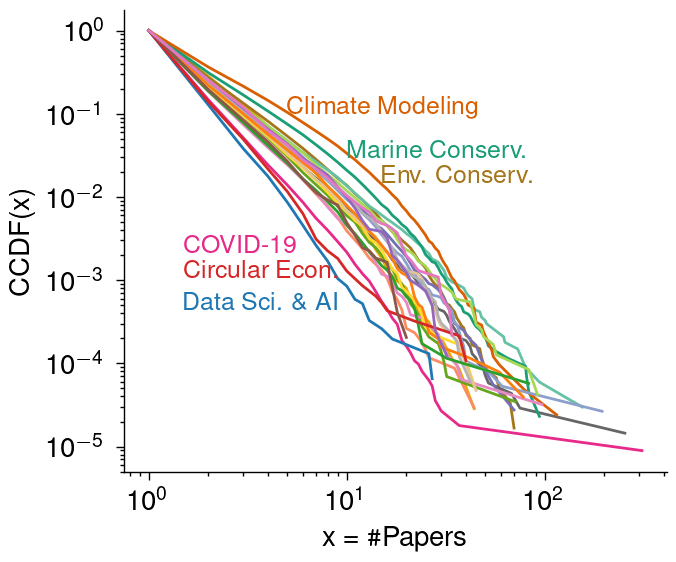

In [26]:

fig, ax = plt.subplots(figsize=(3.5, 3))

data = """
16	Data Science and AI	1.5	0.00045	#fdb462
19	Circular Economy	1.5	0.001088	#d9d9d9
8	Covid19 Pandemic	1.5	0.002172	#bcbd22
1	Environmental Conservation	15	0.015	#ff7f0e
5	Marine Conservation	10	0.03	#8c564b
6	Climate Modeling	5	0.1	#e377c2
"""

def isfloat(value):
    try:
        float(value)
        return True
    except (ValueError, TypeError):
        return False

lines = data.strip().split("\n")
rows = [[float(i) if isfloat(i) else i for i in line.split("\t")] for line in lines]
annotation = pd.DataFrame(rows).set_index(0)

# Plotting
for k, v in policy_cited_scopus.query('partition >= 0').groupby('partition'):
    author_counts = pd.Series(collections.Counter(
        flatten2(v.authids.dropna().apply(lambda x: set(x)))
    ))
    pdf = author_counts.value_counts().sort_index(ascending=False)
    ccdf = pdf.cumsum() / pdf.sum()
    ccdf = ccdf.sort_index()
    
    # Plot line
    ccdf.plot(ax=ax, c=color_list[int(k)], lw=1)

# Annotations
for k, v in annotation.sort_values(2).iterrows():
    # v[1]: Name, v[2]: x, v[3]: y
    ax.annotate(r"{}".format(partition_abbr[v[1]].replace('&','\&')), (v[2], v[3]), c=color_list[int(k)], fontsize=9)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'x = \texttt{\#}Papers')
ax.set_ylabel(r'CCDF(x)')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.tick_params(which='major', direction='out', left=True, bottom=True)
ax.tick_params(which='minor', direction='out', left=True, bottom=True)

plt.savefig(f'../output/figures/figS_power.eps', bbox_inches='tight')
plt.savefig(f'../output/figures/figS_power.pdf', bbox_inches='tight')
plt.show()

In [13]:
import powerlaw

results = []
for k, v in policy_cited_scopus.query('partition >= 0').groupby('partition'):
    author_counts = pd.Series(collections.Counter(
        flatten2(v.authids.dropna().apply(lambda x: set(x)))
    )).values
    
    fit = powerlaw.Fit(author_counts, discrete=True, verbose=False)
    
    R_ln, p_ln = fit.distribution_compare('power_law', 'lognormal')
    R_exp, p_exp = fit.distribution_compare('power_law', 'exponential')
    
    results.append({
        'partition': int(k),
        'alpha': fit.alpha,
        'xmin': fit.xmin,
        'R_vs_lognormal': R_ln,
        'p_lognormal': p_ln,
        'R_vs_exponential': R_exp,
        'p_exponential': p_exp,
    })

df_result = pd.DataFrame(results)
df_result['best_fit'] = df_result.apply(
    lambda r: 'power_law' if (r.R_vs_lognormal > 0 and r.R_vs_exponential > 0) 
              else ('lognormal' if r.R_vs_lognormal < 0 else 'exponential'), axis=1)
print(df_result.to_string(index=False))
df_table = df_result

df_table['partition_name_GPT4'] = partition_info.partition_name_GPT4


# 列を整理
df_table = df_table[[
    'partition_name_GPT4', 'alpha', 'xmin', 
    'R_vs_lognormal', 'p_lognormal', 
    'R_vs_exponential', 'p_exponential'
]]

# p値をフォーマット
def fmt_p(p):
    if p < 0.001:
        exp = int(f'{p:.2e}'.split('e')[1])
        coef = p / (10 ** exp)
        return f'{coef:.1f} \\times 10^{{{exp}}}'
    return f'{p:.3f}'

# LaTeX出力
lines = [
    r'\begin{table}[ht]',
    r'\centering',
    r'\caption{Distribution fitting results for author productivity across research clusters.}',
    r'\label{tab:powerlaw}',
    r'\small',
    r'\begin{tabular}{lcccccc}',
    r'\hline',
    r'Cluster & $\alpha$ & $x_{\min}$ & $R_{\mathrm{PL/LN}}$ & $p$ & $R_{\mathrm{PL/Exp}}$ & $p$ \\',
    r'\hline',
]

for _, r in df_table.iterrows():
    line = f"{r['partition_name_GPT4']} & {r['alpha']:.2f} & {int(r['xmin'])} & {r['R_vs_lognormal']:.1f} & ${fmt_p(r['p_lognormal'])}$ & {r['R_vs_exponential']:.1f} & ${fmt_p(r['p_exponential'])}$ \\\\"
    lines.append(line)

lines += [
    r'\hline',
    r'\end{tabular}',
    r'\vspace{2mm}',
    r'\begin{minipage}{0.9\textwidth}',
    r'\footnotesize',
    r'\textit{Notes:} $\alpha$, power-law exponent; $x_{\min}$, lower bound for fitting. ',
    r'$R_{\mathrm{PL/LN}}$, log-likelihood ratio of power law versus lognormal; ',
    r'$R_{\mathrm{PL/Exp}}$, log-likelihood ratio of power law versus exponential. ',
    r'Positive $R$ favours power law; negative $R$ favours the alternative distribution. ',
    r'All clusters show $R_{\mathrm{PL/Exp}} > 0$, indicating heavy-tailed distributions, ',
    r'while $R_{\mathrm{PL/LN}} < 0$ suggests lognormal provides a better fit than pure power law.',
    r'\end{minipage}',
    r'\end{table}',
]

latex_table = '\n'.join(lines)
print(latex_table)
with open('../output/tables/tab_powerlaw.tex', 'w') as f:
    f.write(latex_table)

 partition    alpha  xmin  R_vs_lognormal  p_lognormal  R_vs_exponential  p_exponential  best_fit
         0 3.626634   6.0       -5.005670 5.233946e-02         24.356972   4.142849e-02 lognormal
         1 2.624056   3.0      -83.314575 8.048402e-18        501.760319   7.034806e-19 lognormal
         2 2.814704   3.0      -33.373171 1.577812e-06        590.814987   1.560775e-08 lognormal
         3 2.654899   4.0      -10.107185 4.428594e-03        267.354689   7.687215e-10 lognormal
         4 3.414113   5.0       -6.270706 2.756787e-02         18.709678   1.172721e-01 lognormal
         5 2.492869   3.0     -117.652286 4.526351e-23        378.585003   9.468773e-11 lognormal
         6 2.180114   2.0     -355.329036 7.660601e-84        993.458555   2.063092e-29 lognormal
         7 2.686233   3.0      -21.507549 4.050975e-06        318.173915   8.244486e-15 lognormal
         8 3.322912   4.0      -13.430864 3.482020e-02        180.590294   1.160864e-01 lognormal
         9 3.117702 

---
# Author Co-authorship Network Analysis

In [14]:

all_authors = set(flatten2(policy_cited_scopus.authids))

authid_country_ = flatten2(policy_cited_scopus.apply(
    lambda x: [[auth, afid, af_country[afid]] 
               for auth, afid in zip(x.authids, x.afids) if afid in af_country],
    axis=1
))
authid_country = pd.DataFrame(authid_country_).groupby(0)[2].agg(lambda x: pd.Series.mode(x)[0])
authid_afname = pd.DataFrame(authid_country_).groupby(0)[1].agg(lambda x: pd.Series.mode(x)[0])
authid_afname = authid_afname.map(af_name)

authid_country = authid_country.loc[list(all_authors & set(authid_country.index))]
authid_afname = authid_afname.loc[list(all_authors & set(authid_afname.index))]

print(f"Authors with country info: {len(authid_country):,}")

Authors with country info: 721,618


In [ ]:

G_alls = {}
G_HIC_SCI = {}
Gccs = {}
G_300 = {}
G_300_cc = {}

for k, v in policy_cited_scopus.query('partition >= 0 and partition < 23').groupby('partition'):
    print(f"Processing partition {k}...")
    
    v2 = v[v.authids.apply(len) < 30]
    authid_eid = authid_eids[k]
    authid_eid['country'] = authid_country
    authid_eid = authid_eid.sort_values('impact', ascending=False)
    
    top_authors = set(flatten2(v.authids.apply(set))) - set([0])
    edge_list = flatten2(v2.authids.apply(
        lambda x: set(x) & set(top_authors)
    ).apply(lambda x: list(itertools.permutations(x, 2))))
    
    if edge_list:
        df = pd.DataFrame(edge_list)
        df['weight'] = 1
        edges = df.groupby([0, 1]).count()['weight'].reset_index()
        G_all = nx.from_pandas_edgelist(edges, source=0, target=1, edge_attr=['weight'])
    else:
        G_all = nx.Graph()
    G_alls[k] = G_all
    
    hic_sci_authors = authid_eid.query('is_hic_sci == 1').index
    edge_list_hic_sci = flatten2(v2.authids.apply(
        lambda x: set(x) & set(hic_sci_authors)
    ).apply(lambda x: list(itertools.permutations(x, 2))))
    
    if edge_list_hic_sci:
        df = pd.DataFrame(edge_list_hic_sci)
        df['weight'] = 1
        edges = df.groupby([0, 1]).count()['weight'].reset_index()
        G = nx.from_pandas_edgelist(edges, source=0, target=1, edge_attr=['weight'])
    else:
        G = nx.Graph()
    G_HIC_SCI[k] = G
    
    if len(G.nodes()) > 0:
        Gcc = G.subgraph(sorted(nx.connected_components(G), key=len, reverse=True)[0])
    else:
        Gcc = G
    Gccs[k] = Gcc
    
    top_authors300 = authid_eid[:300].index
    edge_list_300 = flatten2(v.authids.apply(
        lambda x: set(x) & set(top_authors300)
    ).apply(lambda x: list(itertools.permutations(x, 2))))
    
    if edge_list_300:
        df = pd.DataFrame(edge_list_300)
        df['weight'] = 1
        edges = df.groupby([0, 1]).count()['weight'].reset_index()
        G = nx.from_pandas_edgelist(edges, source=0, target=1, edge_attr=['weight'])
    else:
        G = nx.Graph()
    G_300[k] = G
    
    if len(G.nodes()) > 0:
        Gcc = G.subgraph(sorted(nx.connected_components(G), key=len, reverse=True)[0])
    else:
        Gcc = G
    G_300_cc[k] = Gcc

print("Network construction complete.")

Processing partition 0.0...
Processing partition 1.0...
Processing partition 2.0...
Processing partition 3.0...
Processing partition 4.0...
Processing partition 5.0...
Processing partition 6.0...
Processing partition 7.0...
Processing partition 8.0...
Processing partition 9.0...
Processing partition 10.0...
Processing partition 11.0...
Processing partition 12.0...
Processing partition 13.0...
Processing partition 14.0...
Processing partition 15.0...
Processing partition 16.0...
Processing partition 17.0...
Processing partition 18.0...
Processing partition 19.0...
Processing partition 20.0...
Processing partition 21.0...
Processing partition 22.0...
Network construction complete.


149
294
281
285
123
297
300
279
261
262
288
255
287
226
281
201
42
281
271
39
282
182
254


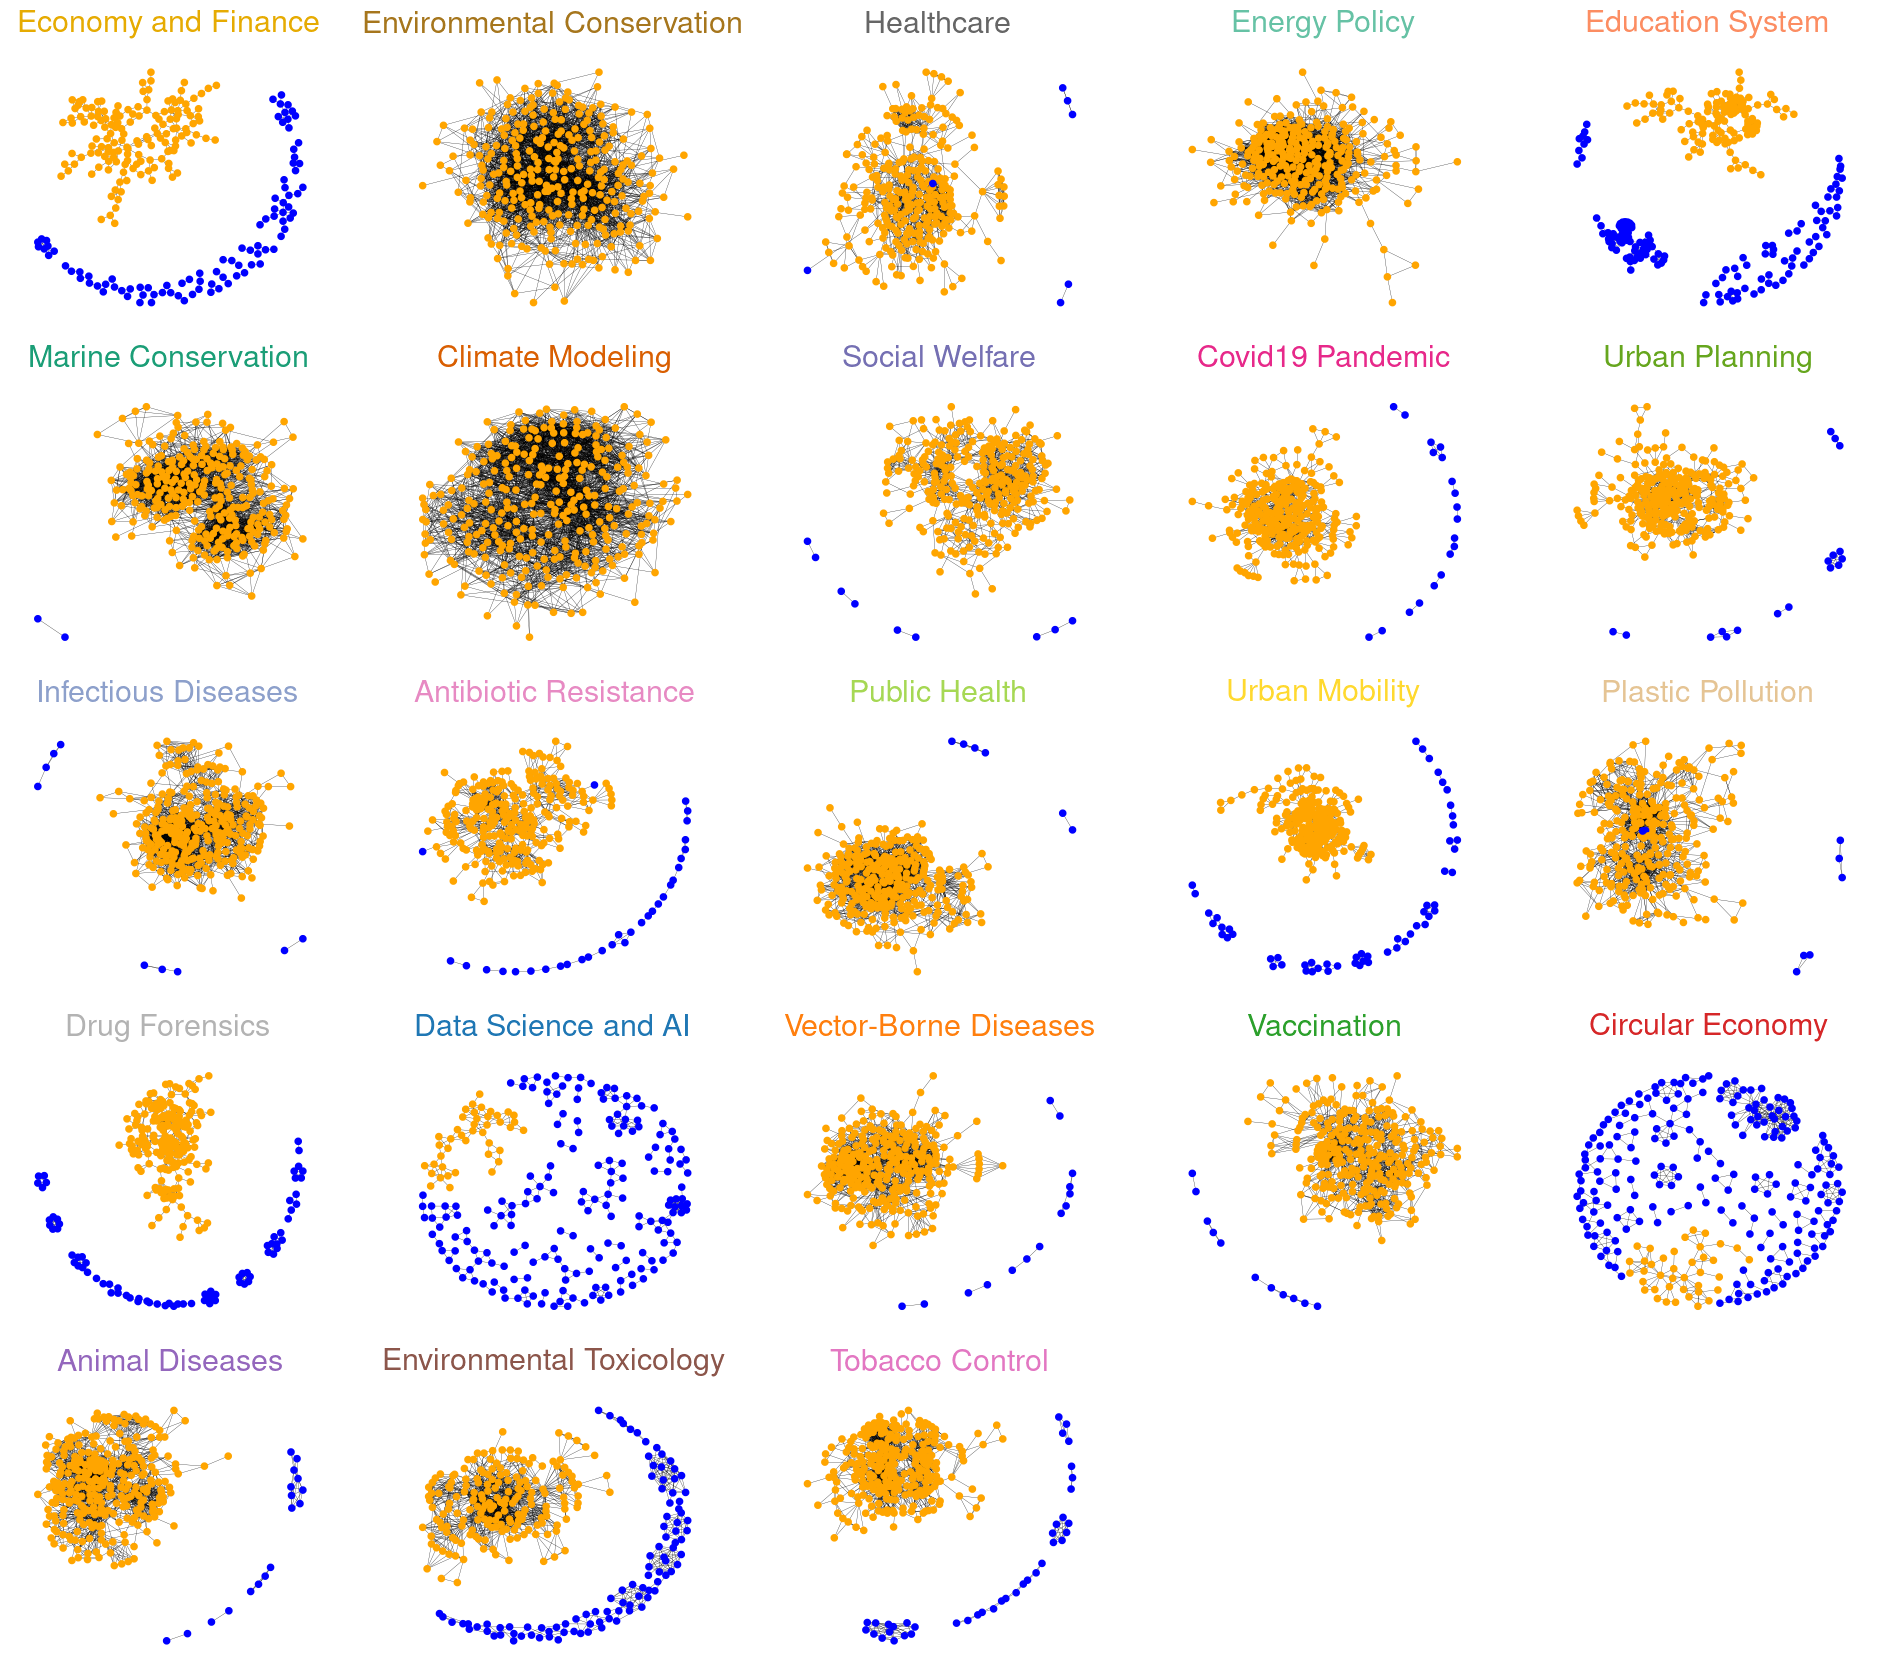

In [16]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Create 5x5 subplot layout
fig, axes = plt.subplots(5, 5, figsize=(12, 10.5))
axes = axes.flatten()

# If you have .png versions or can convert .eps to .png
for i, k in enumerate(range(0,25)):
    if i < 23:
        G = G_300[i]
        Gcc = G_300_cc[i]
        nx.draw(G,pos=kamada(G),node_size=3,width=0.1,node_color=["orange" if c in Gcc.nodes() else 'b' for c in G.nodes()],ax=axes[i])
        
        partition_info.loc[k,'gc_size'] = len(Gcc.nodes())
        print(len(Gcc.nodes()))
        # res[k] = list(Gccs[i].nodes())
        # res_entropy[k] = [scipy.stats.entropy(authid_eid.country.value_counts()),
        #                   scipy.stats.entropy(authid_eid.sample(n=len(Gcc.nodes())).country.value_counts()),
        #                   scipy.stats.entropy(authid_eid.loc[list(Gcc.nodes())].country.value_counts())]
        t = partition_info.partition_name_GPT4.dropna().apply(lambda x: x).loc[k]
        axes[i].set_title(t.replace("&","and"),fontsize=11,c=partition_info.color.dropna().apply(lambda x: x).loc[k] )
    else:
        axes[i].axis('off')
        axes[i].set_visible(False)
        axes[i].set_xticks([])
        axes[i].set_yticks([])
        axes[i].remove()
plt.savefig('../output/figures/S_LCC.eps', format='eps', bbox_inches='tight')
plt.savefig('../output/figures/S_LCC.png',  dpi=200, bbox_inches='tight')

plt.show()


In [17]:
import os
import matplotlib.pyplot as plt
import networkx as nx

output_dir = '../output/figures/coauthor/'

os.makedirs(output_dir, exist_ok=True)

for i, k in enumerate(range(0, 25)):
    if i < 23:

        plt.figure(figsize=(2.4, 2.4)) 
        
        G = G_300[i]
        Gcc = G_300_cc[i]

        nx.draw(G, pos=kamada(G), 
                node_size=10,  
                width=0.5,     
                node_color=["orange" if c in Gcc.nodes() else 'b' for c in G.nodes()])
        
        partition_info.loc[k,'gc_size'] = len(Gcc.nodes())
        print(f"Processing ID {k}: {len(Gcc.nodes())} nodes")

        t = partition_info.partition_name_GPT4.dropna().apply(lambda x: x).loc[k]
        title_text = t.replace("&", "and")
        title_color = partition_info.color.dropna().apply(lambda x: x).loc[k]
        
        plt.title(title_text, fontsize=18, c=title_color)

        filename_base = f'network_{k}' 
        
        save_path_eps = os.path.join(output_dir, f'{filename_base}.eps')
        save_path_png = os.path.join(output_dir, f'{filename_base}.png')

        plt.savefig(save_path_eps, format='eps', bbox_inches='tight')
        plt.savefig(save_path_png, dpi=200, bbox_inches='tight')

        plt.close()

    else:
        pass

Processing ID 0: 149 nodes
Processing ID 1: 294 nodes
Processing ID 2: 281 nodes
Processing ID 3: 285 nodes
Processing ID 4: 123 nodes
Processing ID 5: 297 nodes
Processing ID 6: 300 nodes
Processing ID 7: 279 nodes
Processing ID 8: 261 nodes
Processing ID 9: 262 nodes
Processing ID 10: 288 nodes
Processing ID 11: 255 nodes
Processing ID 12: 287 nodes
Processing ID 13: 226 nodes
Processing ID 14: 281 nodes
Processing ID 15: 201 nodes
Processing ID 16: 42 nodes
Processing ID 17: 281 nodes
Processing ID 18: 271 nodes
Processing ID 19: 39 nodes
Processing ID 20: 282 nodes
Processing ID 21: 182 nodes
Processing ID 22: 254 nodes


In [18]:

def generate_null_model_with_names(graph):
    """Configuration modelによるnullモデル生成"""
    if len(graph.nodes()) == 0:
        return nx.Graph()
    
    node_mapping = {node: i for i, node in enumerate(graph.nodes())}
    reverse_mapping = {i: node for node, i in node_mapping.items()}
    
    integer_graph = nx.relabel_nodes(graph, node_mapping)
    null_model_graph = nx.configuration_model([d for _, d in integer_graph.degree()])
    null_model_graph = nx.Graph(null_model_graph)
    null_model_graph.remove_edges_from(nx.selfloop_edges(null_model_graph))
    null_model_named = nx.relabel_nodes(null_model_graph, reverse_mapping)
    
    return null_model_named

# Null
G_all_nullmodel = {i: generate_null_model_with_names(G) for i, G in G_alls.items()}

null_model_comparison_ = []

for k in range(0, 23):
    n_nodes = len(authid_eids[k])
    rich_club_co = {}
    
    for i in range(1, 51):
        x = int(n_nodes * i / 50)
        nodes = authid_eids[k][:x].index
        actual_edges = len(G_alls[k].subgraph(nodes).edges())
        null_edges = max(len(G_all_nullmodel[k].subgraph(nodes).edges()), 1)
        rich_club_co[i/50] = actual_edges / null_edges
    
    null_model_comparison_.append([
        k,
        len(hic_sci_list.get(k, [])),
        len(G_alls[k].edges()),
        np.mean([j for i, j in list(G_alls[k].degree())]) if G_alls[k].degree() else 0,
        len(G_alls[k].subgraph(hic_sci_list.get(k, [])).edges()),
        len(G_all_nullmodel[k].subgraph(hic_sci_list.get(k, [])).edges()),
        rich_club_co.get(0.02, 0),
        rich_club_co
    ])

null_model_comparison = pd.DataFrame(null_model_comparison_)
null_model_comparison['name'] = partition_info.partition_name_GPT4
null_model_comparison['ratio'] = null_model_comparison[4] / null_model_comparison[5].replace(0, np.nan)

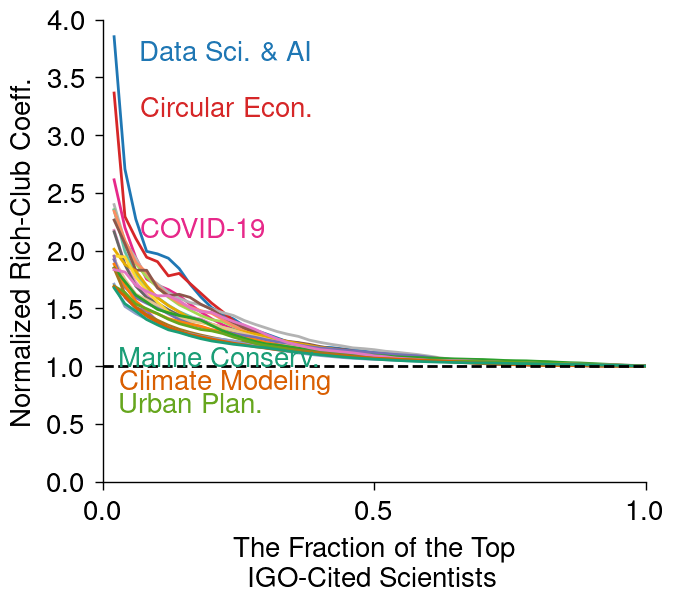

In [28]:

import matplotlib.pyplot as plt

plt.style.use(['science'])

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
})

plt.rcParams["text.latex.preamble"] = r"""
\usepackage{helvet}
\usepackage{sansmath}
\sansmath
\renewcommand{\familydefault}{\sfdefault}
"""

fig, ax = plt.subplots(figsize=(3.5, 3))

sorted_indices = null_model_comparison[6].sort_values(ascending=False).index

for k in sorted_indices:
    rich_club_co = null_model_comparison.loc[k][7]
    pd.Series(rich_club_co).plot(
        label=partition_info.partition_name_GPT4.loc[k],
        color=color_list[k],
        ax=ax
    )




for k, v in null_model_comparison.sort_values(6)[-3:-2].iterrows():
    # v[1]: Name, v[2]: x, v[3]: y
    ax.annotate(r"{}".format(partition_abbr[partition_info.loc[k].partition_name_GPT4].replace('&','\&')), (0.07, v[6]-0.5), c=partition_info.loc[k].color, fontsize=10)

for k, v in null_model_comparison.sort_values(6)[-2:].iterrows():
    # v[1]: Name, v[2]: x, v[3]: y
    ax.annotate(r"{}".format(partition_abbr[partition_info.loc[k].partition_name_GPT4].replace('&','\&')), (0.07, v[6]-0.2), c=partition_info.loc[k].color, fontsize=10)

for i , (k, v) in enumerate(null_model_comparison.sort_values(6)[:3].iterrows()):
    # v[1]: Name, v[2]: x, v[3]: y
    ax.annotate(r"{}".format(partition_abbr[partition_info.loc[k].partition_name_GPT4].replace('&','\&')), (0.03, 1 - i/5), c=partition_info.loc[k].color, fontsize=10)




ax.set_xlim([0, 1])
ax.set_ylim([0, 4])
ax.set_xticks([0, 0.5, 1])

ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.axhline(1, c='black', linestyle='--')
ax.set_ylabel(r'Normalized Rich-Club Coeff.')
ax.set_xlabel(r'The Fraction of the Top' + '\n' + 'IGO-Cited Scientists')

ax.tick_params(which='major', direction='out', left=True, bottom=True)
ax.tick_params(which='minor', left=False, bottom=False)

plt.savefig(f'../output/figures/fig2_e2_richclub.eps', bbox_inches='tight')
plt.savefig(f'../output/figures/fig2_e2_richclub.pdf', bbox_inches='tight')
plt.show()

In [20]:
partition_info.loc[sorted_indices][:2]

,top_tfidf,partition_name_GPT4,num_paper,growth,color,gc_size
16.0,"[data, ai, public, research, digital, article,...",Data Science & AI,4620,1.244101,#1f77b4,42.0
19.0,"[waste, food, circular, recycling, economy, en...",Circular Economy,2842,1.349246,#d62728,39.0
8.0,"[covid, 19, pandemic, cov, sars, patients, hea...",Covid19 Pandemic,12190,5.163312,#e7298a,261.0
15.0,"[drug, samples, ms, forensic, detection, canna...",Drug Forensics,4841,0.249139,#b3b3b3,201.0
12.0,"[food, alcohol, obesity, health, consumption, ...",Public Health,5543,1.061990,#a6d854,287.0
3.0,"[energy, emissions, carbon, climate, electrici...",Energy Policy,13250,1.068435,#66c2a5,285.0
4.0,"[school, students, children, education, learni...",Education System,12696,0.994994,#fc8d62,123.0
21.0,"[hg, mercury, mining, water, mehg, desalinatio...",Environmental Toxicology,1333,0.549841,#8c564b,182.0
11.0,"[antibiotic, resistance, antimicrobial, antibi...",Antibiotic Resistance,5644,1.057401,#e78ac3,255.0
2.0,"[health, care, cancer, patients, studies, qual...",Healthcare,14741,0.991835,#666666,281.0


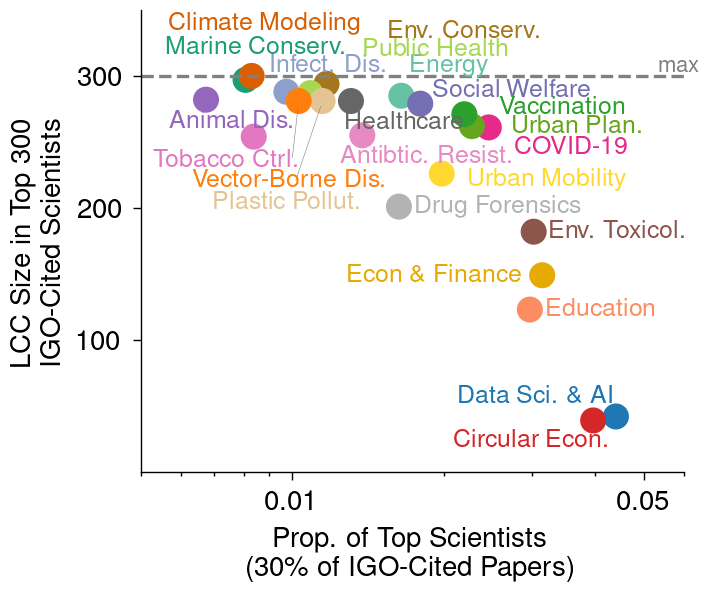

In [29]:
fig, ax = plt.subplots(figsize=(3.5, 3))

output_df = metrics_all.loc[range(0, 23)].copy()
output_df['gc_size'] = [len(G_300_cc[i].nodes()) for i in output_df.index]

ax = output_df.plot.scatter(y='gc_size', x='top30', c='color', s=70, ax=ax)
ax.set_xscale('log')
ax.set_xlim([0.005, 0.06])
ax.set_ylim([0, 350])
ax.set_yticks([100, 200, 300])

ax.set_xlabel('Prop. of Top Scientists \n(30\% of IGO-Cited Papers)')
ax.set_ylabel('LCC Size in Top 300\nIGO-Cited Scientists')

ax.set_xticks([0.01, 0.05])
ax.set_xticklabels(['0.01', '0.05'])
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

right_align_labels = [
    'Drug Forensics', 'Env. Toxicol.', 'Econ \& Finance',
    'Education', 'Data Sci. \& AI'
]

custom_offsets = {
    'Vector-Borne Dis.': (1.5, -60),
    'Tobacco Ctrl.': (1.23, -18),
    'Animal Dis.': (1.5, -16),
    'Infect. Dis.': (1.6, 20),
    'Antibtic. Resist.': (2, -16),
    'Social Welfare': (2.2, 10),
    'Climate Modeling': (1.65, 40),
    'Marine Conserv.': (1.6, 25),
    'Env. Conserv.': (2.7, 40),
    'Public Health': (2.5, 33),
    'Energy': (1.5, 22),
    'Vaccination': (2.1, 5),
    'Urban Plan.': (2.2, 0),
    'Healthcare': (1.7, -16),
    'COVID-19': (1.9, -15),
    'Plastic Pollut.': (1.2, -77),
    'Circular Econ.': (1.08, -15),
    'Urban Mobility': (2.35, -5),
    'Data Sci. \& AI': (1, 15),
    'Econ \& Finance': (0.92, 0)
}

arrow_labels = ['Plastic Pollut.', 'Vector-Borne Dis.']

texts = []
for i, row in output_df.iterrows():
    raw_name = str(row['partition_name'])
    label_text = partition_abbr[raw_name].replace('&', '\&')

    if label_text in custom_offsets:
        x_mult, y_add = custom_offsets[label_text]
        x_pos = row['top30'] * x_mult
        y_pos = row['gc_size'] + y_add

        if label_text in arrow_labels:
            ax.annotate(
                label_text,
                xy=(row['top30'], row['gc_size']),
                xytext=(x_pos, y_pos),
                size=9,
                color=row['color'],
                va='center',
                ha='right',
                arrowprops=dict(
                    arrowstyle='-',
                    color='gray',
                    lw=0.2,
                    zorder=3
                ),
                zorder=10
            )
        else:
            ax.text(
                x_pos,
                y_pos,
                label_text,
                size=9,
                color=row['color'],
                va='center',
                ha='right',
                zorder=10
            )

    elif label_text in right_align_labels or raw_name in right_align_labels:
        ax.text(
            row['top30'] * 1.08,
            row['gc_size'],
            label_text,
            size=9,
            color=row['color'],
            va='center',
            ha='left',
            zorder=10
        )

    else:
        t = ax.text(
            row['top30'],
            row['gc_size'],
            label_text,
            size=9,
            color=row['color'],
            zorder=5
        )
        texts.append(t)

if texts:
    adjust_text(
        texts,
        min_arrow_len=10,
        arrowprops=dict(
            arrowstyle='-',
            color='gray',
            lw=0.2,
            zorder=3
        ),
        expand_points=(1, 1)
    )

ax.tick_params(which='major', direction='out', left=True, bottom=True)
ax.tick_params(which='minor', direction='out', left=False, bottom=True)

ax.axhline(y=300, color='gray', linestyle='--', linewidth=1.2, zorder=1)

ax.text(
    0.065,
    300,
    'max',
    va='bottom',
    ha='right',
    fontsize=8,
    color='gray'
)

plt.savefig('../output/figures/fig2_e_lcc_vs_top30.eps', bbox_inches='tight')
plt.savefig('../output/figures/fig2_e_lcc_vs_top30.pdf', bbox_inches='tight')
plt.show()


---
# International Co-authorship Analysis

In [30]:

res = []
for k, v in policy_cited_scopus.query('partition >= 0').groupby('partition'):
    tpis = set(hic_sci_list.get(k, []))
    v['is_hic_sci'] = v.authids.apply(lambda x: 1 if len(set(x) & tpis) > 0 else 0)
    res.append(v['is_hic_sci'])

policy_cited_scopus['is_hic_sci'] = pd.concat(res)

policy_cited_scopus['len_author'] = policy_cited_scopus.authids.apply(len)

if 'countries' not in policy_cited_scopus.columns:
    policy_cited_scopus['countries'] = policy_cited_scopus.afids.apply(
        lambda x: [af_country.get(y, 'undefined') for y in x] if isinstance(x, list) else []
    )

policy_cited_scopus['intcoauthor'] = policy_cited_scopus.countries.apply(
    lambda x: 1 if len(set(x) - {'undefined'}) > 1 else 0
)

In [ ]:


JOURNAL_SCOPUS_IDS = {
    # General Science
    'Nature': 21206,
    'Science': 23571,
    'PNAS': 21121,
    'Nature Communications': 19700182758,
    'Science Advances': 21100457028,
    'eLife': 21100242814,
    'PLOS One': 10600153309,
    
    # Chemistry
    'ACS Central Science': 21100824912,
    'ACS Nano': 11500153511,
    'Advanced Functional Materials': 25143,
    'Advanced Materials': 19881,
    'Analytical Chemistry': 23915,
    'Angewandte Chemie': 22687,
    'JACS': 22680,
    'Nano Letters': 17853,
    'Nature Chemistry': 18100156701,
    'Nature Materials': 17854,
    'Nature Nanotechnology': 5200152704,
    
    # Physics & Astronomy
    'Physical Review Letters': 29150,
    'Physical Review X': 21100201772,
    'Nature Physics': 4000151822,
    'Nature Photonics': 5700165152,
    'Optica': 21100407195,
    'Astrophysical Journal': 26765,
    'MNRAS': 28218,
    'Nature Astronomy': 21100826565,
    
    # Earth & Environment
    'Nature Climate Change': 21100198409,
    'Nature Geoscience': 17600155041,
    'Nature Sustainability': 21100873499,
    'Global Change Biology': 15131,
    'Environmental Science Technology': 21537,
    'Energy Environmental Science': 17500155114,
    'Geophysical Research Letters': 27962,
    'Water Research': 18795,
    
    # Life Sciences & Medicine
    'Cell': 18434,
    'Cell Reports': 21100201068,
    'Nature Methods': 21100778827,
    'Nature Protocols': 5800207366,
    'Nature Plants': 21100416121,
    'Molecular Cell': 18606,
    'Cancer Research': 29183,
    'Blood': 25454,
    'Brain': 14317,
    'JAMA': 85291,
    'Lancet': 16590,
    'Nature Human Behaviour': 21100838541,
}

def compute_author_concentration_curve(df, max_authors=30, max_sample=10000):
    # フィルタリング (2015-2022)
    df = df.query('year >= 2015 and year <= 2022').copy()
    df['authids'] = df['authids'].apply(lambda x: list(set(x)) if isinstance(x, list) else [])
    df = df[df['authids'].apply(len) <= max_authors]
    df = df[df['authids'].apply(len) > 0]
    if 'doctype' in df.columns:
        df = df[df.doctype.isin(['Article', 'Letter'])]
    
    if len(df) == 0: return None
    
    if len(df) > max_sample:
        df = df.sample(n=max_sample, random_state=42)
    
    authid_eid = pd.DataFrame(
        [[a, eid] for authids, eid in zip(df.authids, df.index) for a in authids]
    )
    authid_eid = authid_eid.groupby(0)[1].agg(list).to_frame()
    authid_eid.columns = ['eids']
    authid_eid['len'] = authid_eid['eids'].apply(len)
    
    impact_data = []
    for authids in df.authids:
        for a in set(authids):
            impact_data.append([a, 1])
    
    if impact_data:
        impact_df = pd.DataFrame(impact_data).groupby(0).sum()
        authid_eid['impact'] = impact_df[1]
    else:
        authid_eid['impact'] = 0
        
    authid_eid = authid_eid.loc[[i for i in authid_eid.index if i != 0]]
    
    authid_eid = authid_eid.sample(frac=1, random_state=42).sort_values('impact', ascending=False)
    
    res = []
    eid_cum = set()
    for eids in authid_eid.eids:
        eid_cum.update(eids)
        res.append(len(eid_cum))
    
    authid_eid['cumsum_eid_len'] = res
    m = authid_eid['cumsum_eid_len'].max()
    authid_eid['cumsum_eid_len_'] = authid_eid['cumsum_eid_len'] / m if m > 0 else 0
    
    return authid_eid.reset_index(drop=True)[['cumsum_eid_len_', 'len']]

def ensure_journal_curves():
    curves_dir = TmpPaths.CURVES_DIR
    if not curves_dir.exists():
        curves_dir.mkdir(parents=True)
        


    print("Generating journal curves (this may take time)...")
    
    print("Loading Scopus data...")
    try:
        papers = pd.concat([
            pd.read_pickle(f'{SCOPUS_BASE}/paper/authids.pickle'),
            pd.read_pickle(f'{SCOPUS_BASE}/paper/journal.pickle')
        ], axis=1)
        papers['year'] = pd.read_pickle(f'{SCOPUS_BASE}/paper/year.pickle')
        papers['doctype'] = pd.read_pickle(f'{SCOPUS_BASE}/paper/doctype.pickle')
        
        # FWCI (Optional)
        try:
            papers['numcited'] = pd.read_pickle(f'{SCOPUS_BASE}/paper/fwci_c4.pickle')
        except:
            papers['numcited'] = pd.read_pickle(f'{SCOPUS_BASE}/paper/num_cited.pickle')
        papers['numcited_r'] = papers['numcited'].rank(pct=True)
        
        print(f"Loaded {len(papers)} papers.")
        
        targets = JOURNAL_SCOPUS_IDS.copy()
        targets['top1per'] = 'top1per'
        targets['sample1per'] = 'sample1per'
        
        for name, jid in targets.items():
            print(f"Processing {name}...")
            if name == 'top1per':
                df = papers.query('numcited_r > 0.99').copy()
            elif name == 'sample1per':
                df = papers.sample(frac=0.01, random_state=42).copy()
            else:
                df = papers[papers['journal'] == int(jid)].copy()
            
            curve = compute_author_concentration_curve(df)
            if curve is not None:
                out_path = curves_dir / f"{name.replace(' ', '_').replace('&', 'and')}.pickle"
                curve.to_pickle(out_path)
                print(f"Saved {out_path}")
                
    except Exception as e:
        print(f"Error generating curves: {e}")
        print("Please ensure Scopus data paths are correct or run 08_journal_comparison.ipynb separately.")

ensure_journal_curves()

Generating journal curves (this may take time)...
Loading Scopus data...
Loaded 88226156 papers.
Processing Nature...
Saved /disks/qnap4/users/t-asatani/code_final/notebooks/../tmp/curves/Nature.pickle
Processing Science...
Saved /disks/qnap4/users/t-asatani/code_final/notebooks/../tmp/curves/Science.pickle
Processing PNAS...
Saved /disks/qnap4/users/t-asatani/code_final/notebooks/../tmp/curves/PNAS.pickle
Processing Nature Communications...
Saved /disks/qnap4/users/t-asatani/code_final/notebooks/../tmp/curves/Nature_Communications.pickle
Processing Science Advances...
Saved /disks/qnap4/users/t-asatani/code_final/notebooks/../tmp/curves/Science_Advances.pickle
Processing eLife...
Saved /disks/qnap4/users/t-asatani/code_final/notebooks/../tmp/curves/eLife.pickle
Processing PLOS One...
Saved /disks/qnap4/users/t-asatani/code_final/notebooks/../tmp/curves/PLOS_One.pickle
Processing ACS Central Science...
Saved /disks/qnap4/users/t-asatani/code_final/notebooks/../tmp/curves/ACS_Central_Sc

In [54]:

general_journals = [
    'Nature', 'Science',
    'Proceedings of the National Academy of Sciences of the United States of America',
    'Nature Communications', 'Science Advances','PNAS'
]
specialized_journals = [
    'Advanced Materials','Analytical Chemistry','Nature Physics','Nature Climate Change','Nature Biotechnology',
    'Journal of the American Chemical Society',
    'Physical Review Letters',
    'Cell','JAMA','Lancet','NEJM'
]
others = ['top1per', 'sample1per', "Scientific Reports", "PLOS One"]

journal_abbr = {
    'Nature': 'Nature',
    'Science': 'Science',
    'Proceedings of the National Academy of Sciences of the United States of America': 'PNAS',
    'Nature Communications': 'Nat. Commun.',
    'Science Advances': 'Sci. Adv.',
    'ACS Nano': 'ACS Nano',
    'Advanced Materials': 'Adv. Mater.',
    'Analytical Chemistry': 'Anal. Chem.',
    'Chemical Communications': 'Chem. Commun.',
    'Journal of the American Chemical Society': 'JACS',
    'Nano Letters': 'Nano Lett.',
    'Nature Chemical Biology': 'Nat. Chem. Biol.',
    'Nature Chemistry': 'Nat. Chem.',
    'Nature Materials': 'Nat. Mater.',
    'Nature Nanotechnology': 'Nat. Nanotechnol.',
    'Nature Astronomy': 'Nat. Astron.',
    'Nature Electronics': 'Nat. Electron.',
    'Nature Energy': 'Nat. Energy',
    'Nature Photonics': 'Nat. Photon.',
    'Nature Physics': 'Nat. Phys.',
    'Physical Review Letters': 'PRL',
    'The Astrophysical Journal': 'ApJ',
    'Nature Climate Change': 'Nat. Clim. Change',
    'Nature Biotechnology': 'Nat. Biotechnol.',
    'Cell': 'Cell',
    'JAMA': 'JAMA',
    'Lancet': 'Lancet',
    'NEJM': 'NEJM',
    'Nature Plants': 'Nat. Plants',
    'Scientific Reports': 'Sci. Rep.',
    'PLOS One': 'PLOS One',
    'top1per': 'Top 0.71\\%',
    'sample1per': 'All Papers',
}

def get_journal_metrics():
    """tmp/curves/*.pickle からジャーナル指標を計算してDF化"""
    curve_files = glob.glob(str(TmpPaths.CURVES_DIR / "*.pickle"))
    out = []
    
    for f in curve_files:
        name = f.split('/')[-1].replace('.pickle', '').replace('_', ' ').replace('and', '&')
        if name == 'Proceedings of the National Academy of Sciences of the United States of America':
            pass # OK
        
        try:
            df = pd.read_pickle(f)
            if df.empty: continue
    
            g = gini(df['len'])

            thr = 0.3

            n_authors = len(df)

            idx = df[df['cumsum_eid_len_'] > thr].index
            if len(idx) > 0:

                top30_author_ratio = (idx[0] + 1) / n_authors
            else:
                top30_author_ratio = 1.0
            

            denom = df['len'].sum()
            shares = df['len'] / denom
            nahhi = nahhi_from_counts(df['len'])
            
            # Grouping
            if name in general_journals: group = 'general'
            elif name in specialized_journals: group = 'specialized'
            elif name in others: group = 'others'
            else: group = 'undefined' 
            
            out.append({
                'journal': name,
                'gini': g,
                'share_below_thr2': top30_author_ratio, # top30 metric
                'nahhi': nahhi,
                'n_authors': n_authors,
                'group': group
            })
            
        except Exception as e:
            print(f"Error processing {name}: {e}")
            
    return pd.DataFrame(out).set_index('journal')

print("Building journal metrics from curves...")
journal_df = get_journal_metrics()
print(f"Journal metrics built: {len(journal_df)} journals")
print(journal_df.head())

Building journal metrics from curves...
Journal metrics built: 48 journals
                           gini  share_below_thr2     nahhi  n_authors  \
journal                                                                  
Nature                 0.197770          0.010670  0.000010      62509   
Science                0.174539          0.011147  0.000012      51941   
PNAS                   0.117600          0.016256  0.000003      66805   
Nature Communications  0.105613          0.015534  0.000002      87874   
Science Advances       0.131667          0.014827  0.000004      75537   

                         group  
journal                         
Nature                 general  
Science                general  
PNAS                   general  
Nature Communications  general  
Science Advances       general  


Plotting Figure 2-c (Top 30%)...
                           gini  share_below_thr2     nahhi  n_authors  \
journal                                                                  
Nature                 0.197770          0.010670  0.000010      62509   
Science                0.174539          0.011147  0.000012      51941   
PNAS                   0.117600          0.016256  0.000003      66805   
Nature Communications  0.105613          0.015534  0.000002      87874   
Science Advances       0.131667          0.014827  0.000004      75537   

                         group  
journal                         
Nature                 general  
Science                general  
PNAS                   general  
Nature Communications  general  
Science Advances       general  
Nature
Science
PNAS
Nat. Commun.
Sci. Adv.
Adv. Mater.
Anal. Chem.
PRL
Nat. Phys.
Nat. Clim. Change
Cell
JAMA
Lancet
PLOS One
Top 0.71\%
All Papers


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


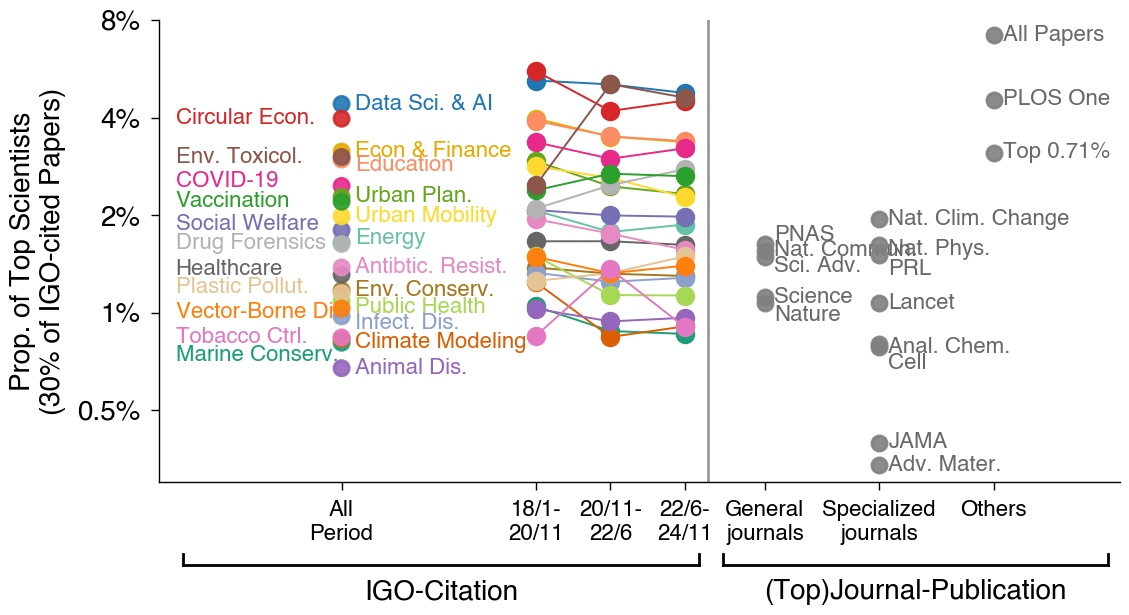

In [55]:
# ========== Figure 2-c / S-gini: Policy vs Journal Comparison (Transposed) ==========

import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
from adjustText import adjust_text

plt.style.use(['science','no-latex'])

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "Helvetica",
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.spines.bottom": True,
    "axes.spines.left": True,
})

plt.rcParams["text.latex.preamble"] = r"""
\usepackage{helvet}
\usepackage{sansmath}
\sansmath
\renewcommand{\familydefault}{\sfdefault}
"""


def remap_x(x_cat):
    mapping = {
        3: 0.2,   # All Period（一番左）
        0: 1.9,   # 18/1-20/11
        1: 2.55,   # 20/11-22/6
        2: 3.2,   # 22/6-24/11
        4: 3.9,   # Gen. journals
        5: 4.9,   # Spec. journals
        6: 5.9,   # Others
    }
    return mapping.get(x_cat, x_cat)
    
sep = 3.4

def _ylabel(metric):
    return {
        'top30': 'Prop. of Top Scientists\n(30% of IGO-cited Papers)',
        'gini':  'Gini (author publication count inequality)',
        'nahhi': 'NAHHI',
        'hhi':   'HHI',
    }.get(metric, metric)


def _journal_y(journal_df, metric):
    if metric == 'top30':
        return journal_df['share_below_thr2'].astype(float)
    elif metric == 'gini':
        return journal_df['gini'].astype(float)
    elif metric == 'nahhi':
        return journal_df['nahhi'].astype(float)
    elif metric == 'hhi':
        N = journal_df['n_authors'].replace(0, np.nan).astype(float)
        return journal_df['nahhi'] * (1 - 1/N) + 1/N
    else:
        raise ValueError(f'unsupported metric for journals: {metric}')


def _by_period_cols(metric):
    if metric == 'top30': return ['top30_0', 'top30_1', 'top30_2']
    if metric == 'gini':  return ['gini_0', 'gini_1', 'gini_2']
    if metric == 'nahhi': return ['nahhi_0', 'nahhi_1', 'nahhi_2']
    if metric == 'hhi':   return ['hhi_0', 'hhi_1', 'hhi_2']
    raise ValueError(metric)


def plot_policy_journal_metric_transposed(metrics_by_pd, metrics_all, journal_df,
                                          metric='top30', annotate=True, ylim=None, filename='test',
                                          partition_offsets=None, journal_offsets=None,figsize=(6.2, 3)):

    if partition_offsets is None:
        partition_offsets = {}
    if journal_offsets is None:
        journal_offsets = {}
    
    cols = _by_period_cols(metric)
    
    fig, ax1 = plt.subplots(figsize=figsize)
    
    all_texts = []

    mp = metrics_by_pd.sort_index()
    for i in mp.index:
        if i >= 23:
            continue
        ys = mp.loc[i, cols].values.astype(float)
        xs = [remap_x(cat) for cat in [0, 1, 2]]
        ax1.plot(xs, ys,
                 c=partition_info.color.loc[i],
                 marker='o', lw=0.7, alpha=1, label=None)

    ma = metrics_all.sort_index()
    ma = ma[ma.index < 23]
    ys_all = ma[metric].astype(float).values
    xs_all = np.full_like(ys_all, fill_value=remap_x(3), dtype=float)
    colors_all = [partition_info.color.loc[i] for i in ma.index]
    ax1.scatter(xs_all, ys_all, c=colors_all, s=30, alpha=0.9, zorder=5)

    if annotate:
        ann_df = ma[[metric]].copy()
        lo4 = ann_df.nsmallest(12, metric)
        hi3 = ann_df.nlargest(11, metric)
        targets = pd.concat([lo4, hi3])
        targets = targets[~targets.index.duplicated(keep='first')]
        
        for i, (pid, row) in enumerate(targets.iterrows()):
            y = float(row[metric])
            x = remap_x(3)
            label = mp.loc[pid]['partition_name'] if 'partition_name' in mp.columns else str(pid)
            abbr_label = partition_abbr[label]
            col = colors_all[int(pid) % len(colors_all)]
            
            y_offset = partition_offsets.get(abbr_label, partition_offsets.get(label, 0))
            
            if i % 2 == 0:
                t = ax1.text(x + 0.12, y + y_offset, abbr_label, fontsize=8, color=col, ha='left', va='center')
            else:
                t = ax1.text(x - 1.45, y + y_offset, abbr_label, fontsize=8, color=col, ha='left', va='center')
            all_texts.append(t)

    df_general     = journal_df.query('group=="general"').copy()
    df_specialized = journal_df.query('group=="specialized"').copy()
    df_others      = journal_df.query('group=="others"').copy()

    y_general      = _journal_y(df_general, metric)
    y_specialized  = _journal_y(df_specialized, metric)
    y_others       = _journal_y(df_others, metric)

    def scatter_vals(ys, x_value):
        if ys.size == 0:
            return
        ax1.scatter(np.full(len(ys), x_value), ys, c='gray', s=30, alpha=0.9, zorder=5)

    scatter_vals(y_general.values,     remap_x(4))
    scatter_vals(y_specialized.values, remap_x(5))
    scatter_vals(y_others.values,      remap_x(6))

    # 雑誌注釈
    def add_journal_texts(df_sub, x_val, filter_fn=None):
        if df_sub.empty:
            return
        labels = df_sub.index.to_series()
        ys = _journal_y(df_sub, metric)
        
        for idx, y in ys.items():
            label_raw = labels.loc[idx]
            label = journal_abbr.get(label_raw, label_raw)
            print(label)
            if (filter_fn is None) or filter_fn(label):
                # 辞書からオフセット取得（キーはlabelまたはlabel_rawどちらでも可）
                y_offset = journal_offsets.get(label, journal_offsets.get(label_raw, 0))
                
                t = ax1.text(float(x_val) + 0.08, float(y) + y_offset, 
                            str(label).replace("&", "and").replace("\\", ""),
                            fontsize=8, color='dimgray', ha='left', va='center')
                all_texts.append(t)
    
    print(df_general)
    if annotate:
        add_journal_texts(df_general, remap_x(4))
        add_journal_texts(df_specialized, remap_x(5))
        add_journal_texts(df_others, remap_x(6))

    ax1.set_ylim(*ylim)

    ax1.set_xlim(-1.4, 7)
    
    if metric == 'top30':
        ax1.set_yscale('log')
        ax1.set_yticks([0.005, 0.01, 0.02, 0.04, 0.08])
        ax1.set_yticklabels(["0.5%", "1%", "2%", "4%", "8%"])

    ax1.set_ylabel(_ylabel(metric), fontsize=10)
    ax1.set_xlabel("")

    ax1.set_xticks([remap_x(i) for i in [3, 0, 1, 2, 4, 5, 6]])
    ax1.set_xticklabels([
        'All\nPeriod',
        '18/1-\n20/11',
        '20/11-\n22/6',
        '22/6-\n24/11',
        'General\njournals',
        'Specialized\njournals',
        'Others',
    ], fontsize=8)
    
    for side in ['right', 'top']:
        ax1.spines[side].set_visible(False)

    ax1.axvline(x=sep, color='gray', lw=1.0, ls='-', alpha=0.8)

    xlim_range = 8.0  # -0.5 to 8.5
    x_policy_left  = (0.0 + 0.2) / xlim_range
    x_policy_right = (4 +  0.5) / xlim_range
    x_journal_left  = (4 + 0.7) / xlim_range
    x_journal_right = (7.0 + 0.9) / xlim_range
    y_bracket = -0.18
    
    ax1.plot([x_policy_left, x_policy_right], [y_bracket, y_bracket], 
             transform=ax1.transAxes, color='black', lw=1.0, clip_on=False)
    ax1.plot([x_policy_left, x_policy_left], [y_bracket, y_bracket + 0.025], 
             transform=ax1.transAxes, color='black', lw=1.0, clip_on=False)
    ax1.plot([x_policy_right, x_policy_right], [y_bracket, y_bracket + 0.025], 
             transform=ax1.transAxes, color='black', lw=1.0, clip_on=False)
    ax1.text((x_policy_left + x_policy_right) / 2, y_bracket - 0.03, 'IGO-Citation',
             va='top', ha='center', fontsize=10, transform=ax1.transAxes)

    ax1.plot([x_journal_left, x_journal_right], [y_bracket, y_bracket], 
             transform=ax1.transAxes, color='black', lw=1.0, clip_on=False)
    ax1.plot([x_journal_left, x_journal_left], [y_bracket, y_bracket + 0.025], 
             transform=ax1.transAxes, color='black', lw=1.0, clip_on=False)
    ax1.plot([x_journal_right, x_journal_right], [y_bracket, y_bracket + 0.025], 
             transform=ax1.transAxes, color='black', lw=1.0, clip_on=False)
    ax1.text((x_journal_left + x_journal_right) / 2, y_bracket - 0.03, '(Top)Journal-Publication',
             va='top', ha='center', fontsize=10, transform=ax1.transAxes)

    ax1.tick_params(which='major', direction='out', top=False, right=False, left=True, bottom=True)
    ax1.tick_params(which='minor', left=False, top=False, right=False, bottom=False)

    plt.savefig(f'{filename}.pdf', bbox_inches='tight')
    plt.savefig(f'{filename}.eps', bbox_inches='tight', dpi=150)
    plt.show()
    plt.close()


partition_offsets_top30 = {
    "COVID-19": 0.0008,
    "Plastic Pollut.": 0.0005,
    "Vector-Borne Dis.": -0.0003,
    "Marine Conserv.": -0.0007,
    "Healthcare": 0.0005,
    "Social Welfare": 0.0007,
    "Education": -0.0012,
    "Energy": 0.0005,
    "Infect. Dis.": -0.0005,
    "Public Health": -0.0005,
    "Climate Modeling": -0.0002,
}

journal_offsets_top30 = {
    "PNAS": 0.001,
    "Sci. Adv.": -0.001,
    "Nature": -0.0009,
    "Nat. Phys.": -0.0005,
    "PRL": -0.0015,
    "Cell": -0.001,
}


print("Plotting Figure 2-c (Top 30%)...")
plot_policy_journal_metric_transposed(
    metrics_by_period, metrics_all, 
    journal_df.query('group != "undefined"'), 
    metric='top30',
    filename='../output/figures/fig2_c_top30_comparison', 
    annotate=True,
    ylim=(0.003, 0.08),
    partition_offsets=partition_offsets_top30,
    journal_offsets=journal_offsets_top30
)


Plotting Figure S-gini (Gini)...
                           gini  share_below_thr2     nahhi  n_authors  \
journal                                                                  
Nature                 0.197770          0.010670  0.000010      62509   
Science                0.174539          0.011147  0.000012      51941   
PNAS                   0.117600          0.016256  0.000003      66805   
Nature Communications  0.105613          0.015534  0.000002      87874   
Science Advances       0.131667          0.014827  0.000004      75537   

                         group  
journal                         
Nature                 general  
Science                general  
PNAS                   general  
Nature Communications  general  
Science Advances       general  
Nature
Science
PNAS
Nat. Commun.
Sci. Adv.
Adv. Mater.
Anal. Chem.
PRL
Nat. Phys.
Nat. Clim. Change
Cell
JAMA
Lancet
PLOS One
Top 0.71\%
All Papers


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


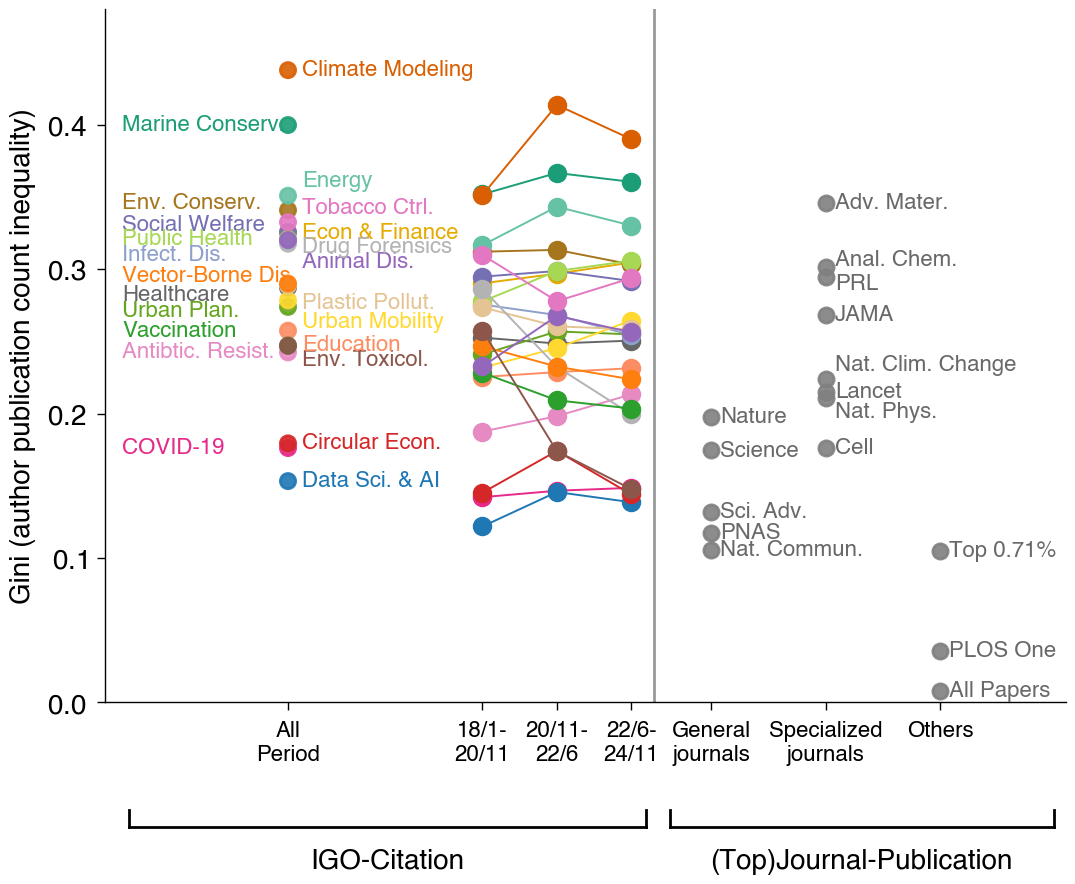

In [56]:
partition_offsets_gini = {
    'Climate Modeling': 0,
    'Marine Conserv.': 0,
    'Env. Conserv.': 0.005,
    'Social Welfare': 0.005,
    'Infect. Dis.': -0.01,
    'Energy': 0.01,
    'Tobacco Ctrl.': 0.01,
    'Econ. & Finance': 0.005,
    'Animal Dis.': -0.015,
    'Healthcare': -0.005,
    'Drug Forensics': -0.002,
    'Vector-Borne Dis.': 0.005,
    'Urban Mobility': -0.015,
    'Plastic Pollut.': -0.012,
    'Vaccination': 0.01,
    'Antibiotic Resist.': 0,
    'Urban Plan.': -0.0025,
    'Education': -0.01,
    'Env. Toxicol.': -0.01,
    'COVID-19': 0,
    # 'Circular Econ.': 0.01,
    # 'Data Sci. & AI': -0.01,
}
journal_offsets_gini = {
    'Adv. Mater.': 0,
    'Anal. Chem.': 0.005,
    'PRL': -0.005,
    'JAMA': 0,
    'Nat. Clim. Change': 0.01,
    'Lancet': 0,
    'Nat. Phys.': -0.01,
    # 'Nature': 0.01,
    # 'Science': -0.01,
    'Cell': 0,
    'PNAS': 0,

    'Top 0.71%': 0,
    'PLOS One': 0,
    'All Papers': 0,
}

print("Plotting Figure S-gini (Gini)...")
plot_policy_journal_metric_transposed(
    metrics_by_period, metrics_all, 
    journal_df.query('group != "undefined"'), 
    metric='gini',figsize=(6.2, 4.5),
    filename='../output/figures/figS_gini_comparison', 
    annotate=True,
    ylim=(0.0, 0.48),
    partition_offsets=partition_offsets_gini,
    journal_offsets=journal_offsets_gini
)

In [57]:
partition_info.partition_name_GPT4.dropna()

0.0            Economy and Finance
1.0     Environmental Conservation
2.0                     Healthcare
3.0                  Energy Policy
4.0               Education System
5.0            Marine Conservation
6.0               Climate Modeling
7.0                 Social Welfare
8.0               Covid19 Pandemic
9.0                 Urban Planning
10.0           Infectious Diseases
11.0         Antibiotic Resistance
12.0                 Public Health
13.0                Urban Mobility
14.0             Plastic Pollution
15.0                Drug Forensics
16.0             Data Science & AI
17.0         Vector-Borne Diseases
18.0                   Vaccination
19.0              Circular Economy
20.0               Animal Diseases
21.0      Environmental Toxicology
22.0               Tobacco Control
Name: partition_name_GPT4, dtype: object

In [58]:
metrics_all.to_pickle('../tmp/metrics_all.pickle')

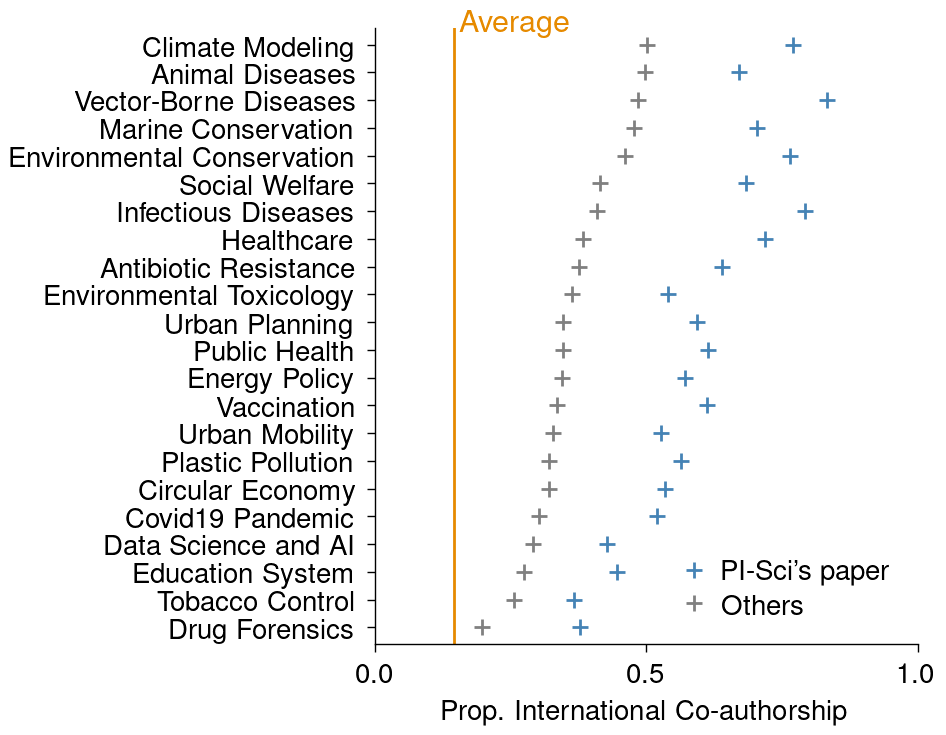

In [ ]:

import matplotlib.pyplot as plt

plt.style.use(['science'])

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "axes.spines.right": False,
    "axes.spines.top": False,
})

plt.rcParams["text.latex.preamble"] = r"""
\usepackage{helvet}
\usepackage{sansmath}
\sansmath
\renewcommand{\familydefault}{\sfdefault}
"""


int_co_author_all = pd.read_pickle(f'{SCOPUS_BASE}/paper/countries.pickle').apply(set).apply(len).apply(lambda x: 1 if x >= 2 else 0).mean()

plot_df = policy_cited_scopus.query('len_author >= 1 and year <= 2023').groupby(
    ['partition', 'is_hic_sci']
)['intcoauthor'].agg(['mean', 'sem']).unstack()

plot_df = plot_df.iloc[1:]  # partition=0を除外
plot_df.index = [(partition_info.loc[i].partition_name_GPT4).replace('&', 'and') for i in plot_df.index]
plot_df = plot_df.sort_values(('mean', 0))

means = plot_df['mean']
y_positions = range(len(means))

fig, ax = plt.subplots(figsize=(3.5, 4))

ax.errorbar(means[1], y_positions, fmt='+', capsize=5, color='#4583B5', label="PI-Sci's paper")
ax.errorbar(means[0], y_positions, fmt='+', capsize=5, color='#808080', label='Others')

ax.set_yticks(y_positions)
ax.set_yticklabels(means.index)
ax.set_xlabel(r'Prop. International Co-authorship')
ax.set_xticks([0, 0.5, 1])
ax.set_xlim([0, 1])
ax.set_ylim([-0.6, len(means) - 0.4])
ax.legend(loc='lower right', handletextpad=0, labelspacing=0.3).set_title('')

plt.minorticks_off()
plt.axvline(int_co_author_all, c='#e68a00')
ax.annotate('Average', (int_co_author_all + 0.01, 21.5), fontsize=11, c='#e68a00')

ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.tick_params(which='major', direction='out', left=True, bottom=True)
ax.tick_params(which='minor', left=False, bottom=False)

plt.savefig(f'../output/figures/fig4_intl_coauthor.eps', bbox_inches='tight')
plt.savefig(f'../output/figures/fig4_intl_coauthor.pdf', bbox_inches='tight')
plt.show()

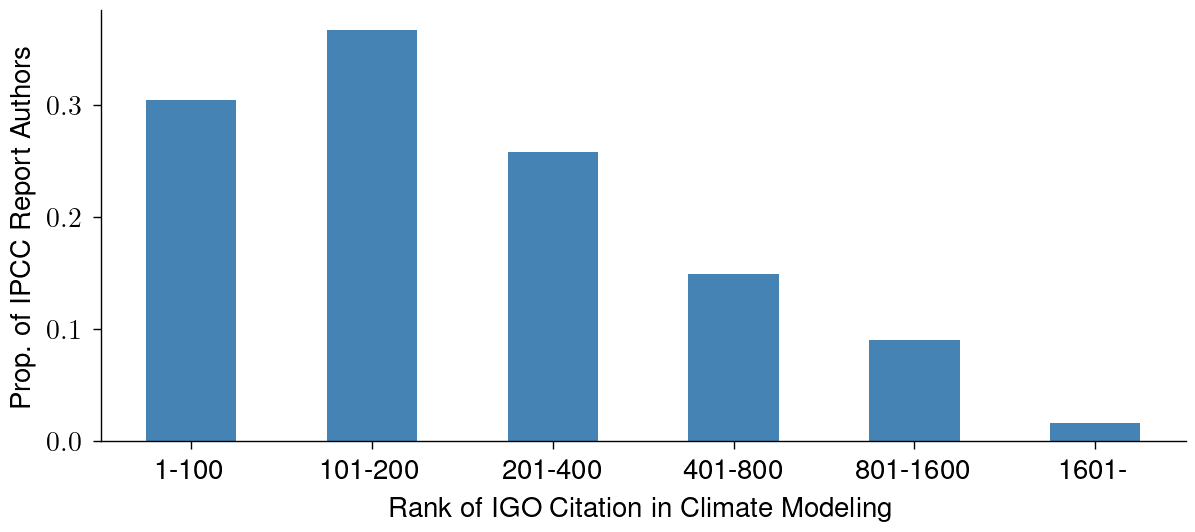

In [ ]:

def classify_logarithmic_bins_base2(data):

    data = np.array(data)+1
    
    min_val = max(data.min(), 1)  # Start from at least 2^0 = 1
    max_val = data.max()
    
    min_exp = np.floor(np.log2(min_val))
    max_exp = np.ceil(np.log2(max_val))
    bins = 2 ** np.arange(min_exp, max_exp + 1)
    
    classifications = np.digitize(data, bins, right=True)
    
    return classifications
classify_logarithmic_bins_base2([1,2,3])


is_ipcc = pd.read_csv('../data/external/climate_modeling_authors_with_ipcc.csv').set_index('0').is_ipcc
climate_modeling_author = authid_eids[6]
climate_modeling_author['is_ipcc'] = is_ipcc
climate_modeling_author['is_ipcc'] = climate_modeling_author['is_ipcc'].apply(lambda x:1 if x=='YES' else 0)
climate_modeling_author['rank'] = climate_modeling_author.impact.rank(ascending=False)
climate_modeling_author['rank_bin'] = classify_logarithmic_bins_base2(climate_modeling_author['rank'].apply(lambda x: int((x-1)/100)))


fig, ax = plt.subplots(figsize=(7, 2.8))

plt.style.use(['science']) 

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"], 
    "axes.spines.right": False,
    "axes.spines.top": False,
})

plt.rcParams['text.latex.preamble'] = r'\usepackage{helvet}\renewcommand{\familydefault}{\sfdefault}'



climate_modeling_author['rank_bin'] = climate_modeling_author.rank_bin.apply(lambda x: min(5,x))
climate_modeling_author.groupby('rank_bin').is_ipcc.mean().plot.bar(ax=ax,color='#4583B5')
ax.set_ylabel(r'Prop. of IPCC Report Authors')
ax.set_xlabel(r'Rank of IGO Citation in Climate Modeling')
ax.set_xticklabels(["1-100","101-200","201-400","401-800","801-1600","1601-"],rotation=0)


ax.xaxis.set_ticks_position('bottom')  # または 'both'
ax.yaxis.set_ticks_position('left')    # または 'both'

ax.tick_params(which='major', direction='out', left=True, bottom=True)
ax.tick_params(which='minor', direction='out', left=True, bottom=True)
ax.tick_params(which='minor', left=False, bottom=False)

plt.savefig('../output/figures/6.5.eps', bbox_inches='tight')
plt.savefig('../output/figures/6.5.pdf', bbox_inches='tight')
plt.show()




 

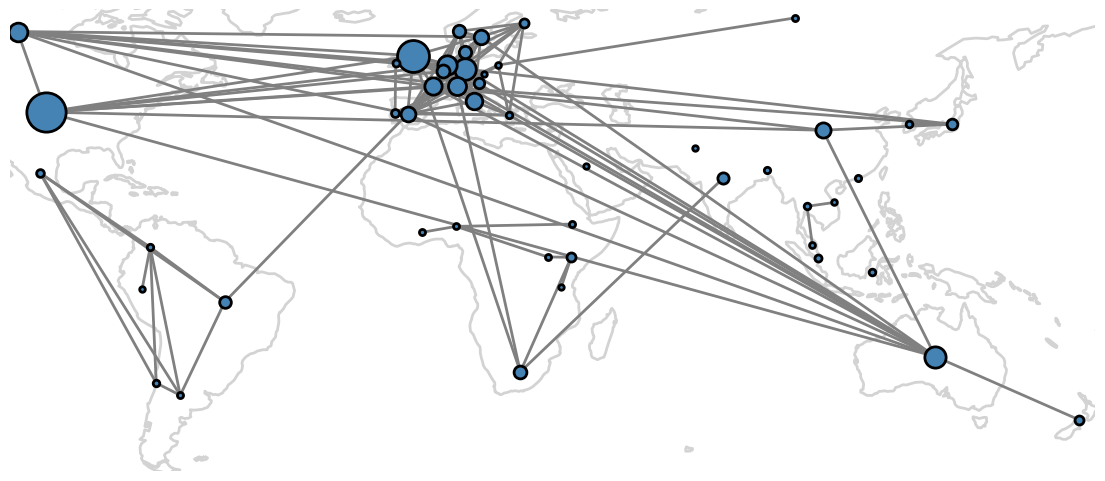

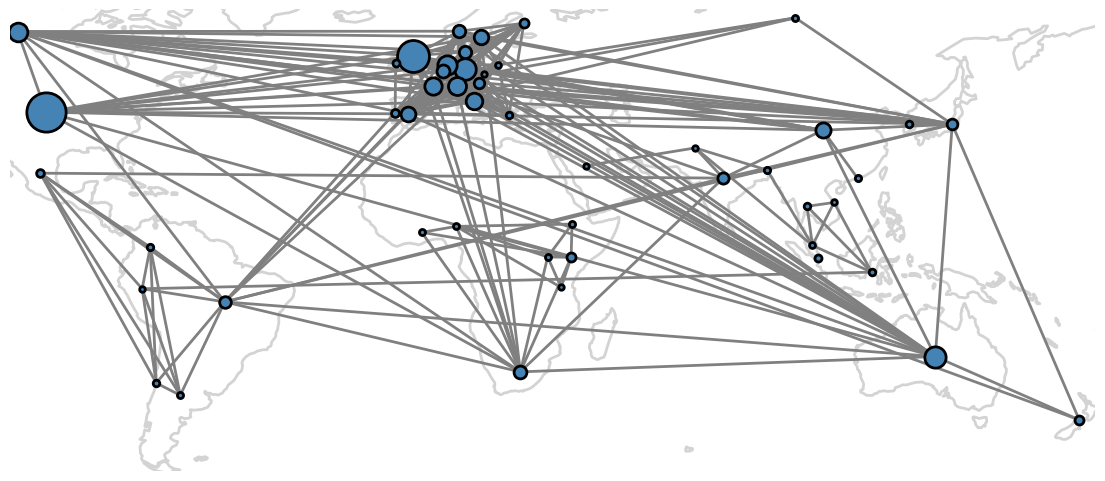

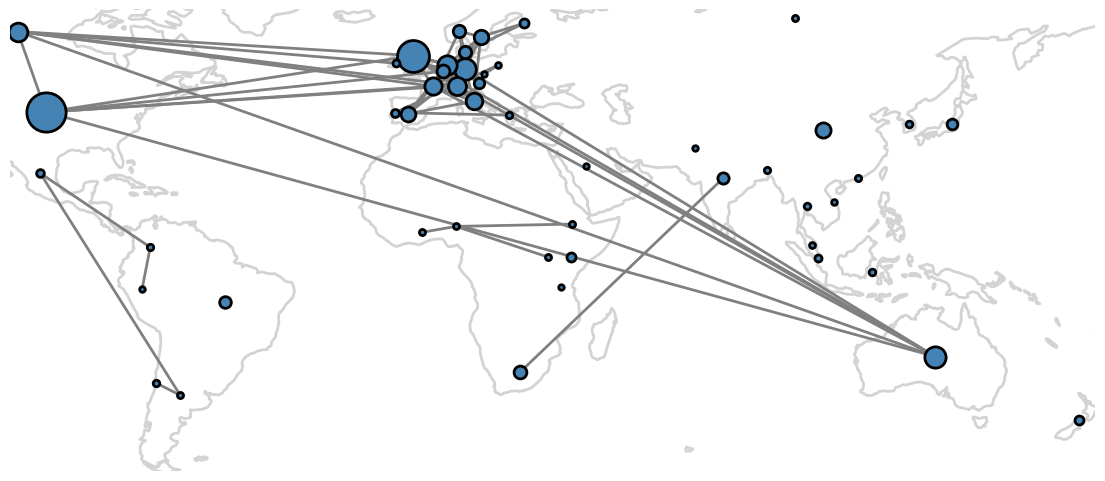

In [64]:
from geopy.geocoders import Nominatim
import time
geolocator = Nominatim(user_agent="my_app")
country_coords = {}
def get_country_coords(country_name):
    if country_name in country_coords:
        return country_coords[country_name]
    location = geolocator.geocode(country_name)
    if location:
        country_coords[country_name] = (location.latitude, location.longitude)
        return (location.latitude, location.longitude)
    return None


plt.style.use(['science']) 

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
})

plt.rcParams['text.latex.preamble'] = r'\usepackage{helvet}\renewcommand{\familydefault}{\sfdefault}'



for f,thr in zip(['5','S5_1','S5_2'],[0.065,0.05,0.08]):
    policy_cited_scopus_ = policy_cited_scopus.query('partition>=0 and is_hic_sci==1')
    # Generate edges and node attributes (using your provided data)
    tmp = pd.DataFrame(flatten2(policy_cited_scopus_.countries.apply(lambda x: itertools.combinations(sorted(set(x)), 2))))
    tmp['c'] = 1
    edges = tmp.groupby([0, 1]).count()[['c']].reset_index()
    country_count = pd.Series(collections.Counter(flatten2(policy_cited_scopus_.countries.apply(lambda x: set(x) - set(['undefined'])))))
    edges['papers0'] = edges[0].map(country_count)
    edges['papers1'] = edges[1].map(country_count)
    edges['jaccard'] = edges['c'] / (edges['papers0'] + edges['papers1'] - edges['c'])
    edges = edges.query('jaccard>@thr')
    edges = edges.query('papers0>500 and papers1 > 500')
    
    G = nx.from_pandas_edgelist(edges, source=0, target=1)
    [G.add_node(n) for n in country_count[country_count > 500].index if n not in G.nodes()]
    
    node_positions = {node: get_country_coords(node) for node in G.nodes}
    
    # Load world map
    import geodatasets
    import geopandas as gpd
    
    world = gpd.read_file(geodatasets.get_path('naturalearth.land')) # or 'naturalearth_lowres' if available under that exact name
    
    # Plot the world map
    fig, ax = plt.subplots(figsize=(7, 5))
    world.boundary.plot(ax=ax, color='lightgray')
    map_pos = {node: (lon, lat) for node, (lat, lon) in node_positions.items()}
    node_sizes = [country_count.loc[node] * 200 / country_count.max() for node in G.nodes if node in country_count]
    for node, (x, y) in map_pos.items():
        ax.scatter(x, y, s=node_sizes.pop(0), color="#4583B5", edgecolors="black", zorder=5)
    
    for edge in G.edges:
        if edge[0] in map_pos and edge[1] in map_pos:
            x_coords = [map_pos[edge[0]][0], map_pos[edge[1]][0]]
            y_coords = [map_pos[edge[0]][1], map_pos[edge[1]][1]]
            ax.plot(x_coords, y_coords, color="gray", linewidth=1, zorder=3)

    
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim([-110,177])
    ax.set_ylim([-55,67])
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    plt.savefig(f'../output/figures/{f}.eps', bbox_inches='tight')
    plt.savefig(f'../output/figures/{f}.pdf', bbox_inches='tight')
    plt.show()


In [63]:

all_authors = set(flatten2(policy_cited_scopus.authids))
authid_country_ = flatten2(policy_cited_scopus.apply(
    lambda x: [[auth, afid, af_country[afid]] for auth, afid in zip(x.authids, x.afids) if afid in af_country], axis=1))
authid_country = pd.DataFrame(authid_country_).groupby(0)[2].agg(lambda x: pd.Series.mode(x)[0])
authid_afname = pd.DataFrame(authid_country_).groupby(0)[1].agg(lambda x: pd.Series.mode(x)[0]).map(af_name)
authid_country = authid_country.loc[list(all_authors & set(authid_country.index))]
authid_afname = authid_afname.loc[list(all_authors & set(authid_afname.index))]

for k in range(23):
    if k not in authid_eids:
        continue
    df = authid_eids[k].copy()
    df['authid'] = df.index
    df['name'] = df['authid'].map(author_name)
    df['main_aff'] = df['authid'].map(authid_afname)
    df['country'] = df['main_aff'].dropna().apply(lambda x: x.split("_")[-1] if isinstance(x, str) else "")
    df['affliation'] = df['main_aff'].dropna().apply(lambda x: x.split("_")[0] if isinstance(x, str) else "")
    df['country'] = df['country'].fillna("NO DATA")
    df['affliation'] = df['affliation'].fillna("NO DATA")
    
    partition_info.loc[k, 'top_authors'] = ", ".join(
        df[:10].apply(lambda x: "{}: {} ({})".format(
            str(x['name']).replace("_", " "), x['affliation'], x['country'].upper()), axis=1))

policy_cited_scopus['country_count'] = policy_cited_scopus.afids.apply(
    lambda x: [af_country[y] for y in x if y in af_country]).apply(lambda x: [(y, 1/len(x)) for y in x] if len(x) > 0 else [])
policy_cited_scopus['af_count'] = policy_cited_scopus.afids.apply(
    lambda x: [af_name.loc[y] for y in x if y in af_name.index]).apply(lambda x: [(y, 1/len(x)) for y in x] if len(x) > 0 else [])

partition_info['country_count'] = policy_cited_scopus.groupby('partition').country_count.apply(
    lambda x: list(pd.DataFrame(flatten2(x)).groupby(0).sum()[1].sort_values(ascending=False)[:10].index) if len(flatten2(x)) > 0 else [])
partition_info['af_count'] = policy_cited_scopus.groupby('partition').af_count.apply(
    lambda x: list(pd.DataFrame(flatten2(x)).groupby(0).sum()[1].sort_values(ascending=False)[:10].index) if len(flatten2(x)) > 0 else [])

partition_info_output = partition_info.copy().loc[range(0, 23)]
partition_info_output['top_authors'] = partition_info_output['top_authors'].fillna("")
partition_info_output['country_count'] = partition_info_output['country_count'].apply(lambda x: ", ".join(x[:15]) if isinstance(x, list) else "")
partition_info_output['af_count'] = partition_info_output['af_count'].apply(lambda x: ", ".join([y[:-4] for y in x[:10]]) if isinstance(x, list) else "")

color_map = {'blue': "Social Science", 'green': "Environment", 'orange': "Health Care"}
if 'color' in partition_info_output.columns:
    partition_info_output['category'] = partition_info_output['color'].map(color_map)


print(partition_info_output[['partition_name_GPT4', 'top_authors', 'country_count', 'af_count']].head())


df = partition_info_output.sort_values(['color','num_paper'],ascending=[True,False])[['color','partition_name_GPT4','num_paper','top_tfidf','country_count','af_count','top_authors']]
df = df[df.top_authors.apply(len)>0]
df

caption = r"\caption{\textbf{Table S2} Summary of 23 clusters of IGO-cited papers: This table presents an overview of clusters: category, cluster name, the number of papers, top TF-IDF terms, top countries, top institutions, and top scientists of each cluster. }"

head = r"""\begin{table*}[ht]
\footnotesize
\centering
\begin{tabular}{|p{1.8cm}|p{2.5cm}|p{1.1cm}|p{3.2cm}|p{2.1cm}|p{4.7cm}|}
\hline
\textbf{Category} & \textbf{Cluster Name} & \textbf{\texttt{\#}Papers} & \textbf{Top TF-IDF Words} & \textbf{Top Countries} & \textbf{Top Institutions} \\
\hline
\hline
"""

foot = r"""
\end{tabular}
\label{tab:environmental_summary}
\end{table*}
"""

output_latex = ""

for i in range(0,25,5):
    if i == 0:
        output_latex += head.replace("\\centering","\\centering\n"+caption)
    else:
        output_latex += head
    for k,v in df.iloc[i:i+5].iterrows():
        output_latex +=  """\\textbf{AAA} & \\textbf{BBB} & CCC & DDD & EEE & FFF \\\\
        \multicolumn{6}{|p{17.7cm}|}{\\textbf{Top Authors:} GGG } \\\\
        \hline""".replace("AAA",v.color).replace("BBB",v.partition_name_GPT4).replace("CCC",str(int(v.num_paper))).replace("DDD","".join(v.top_tfidf[:15])).replace("EEE",v.country_count).replace("FFF",v.af_count).replace("GGG",v.top_authors).replace(r"Data Science & AI",r"Data Science and AI")
    output_latex +=  foot
    output_latex += "\n"
with open("../output/tables/cluster_info.tex", 'w') as file:
    # Write the content to the file
    file.write(output_latex)


            partition_name_GPT4  \
0.0         Economy and Finance   
1.0  Environmental Conservation   
2.0                  Healthcare   
3.0               Energy Policy   
4.0            Education System   

                                           top_authors  \
0.0  Rodríguez-Pose Andrés: London School of Econom...   
1.0  Herrero Mario: CSIRO (AUS), Watson James E. M....   
2.0  Schünemann Holger J.: McMaster University (CAN...   
3.0  van Vuuren Detlef P.: PBL Netherlands Environm...   
4.0  Rozelle Scott: Stanford University (USA), Trem...   

                                        country_count  \
0.0  usa, gbr, deu, chn, ita, fra, nld, esp, can, che   
1.0  usa, gbr, chn, deu, aus, nld, bra, can, fra, ita   
2.0  usa, gbr, aus, can, chn, nld, che, deu, zaf, ind   
3.0  usa, gbr, chn, deu, aus, nld, swe, fra, esp, can   
4.0  usa, gbr, aus, deu, can, chn, nld, esp, swe, nor   

                                              af_count  
0.0  International Monetary Fund, World 